# Обработка и анализ табличных данных

In [2]:
import pandas as pd

In [95]:
table_data = pd.read_excel("./data_raw/DataSet_V49 (2).xlsx")

### Пустые или неинформативные даныне

In [96]:
table_data.drop(["Bypass#", 'Повторная оперция', 'Тип повторной операции', 'Плохая мобильность', 'Открытая перация на сердце в анамнезе', 
                 'Ход операции', 'Протокол коронарографии', 'Коррекция А-В блокады', 'Исход А-В блокады', 'Начало А-В блокады (До/после ЧКВ)',
                   'Инфаркт-зависимая артерия(Огригированная)', 'Инфаркт-зависимая артерия(Огригированная)2', 'Unnamed: 344',
                   'SYNTAX Score', 'ОНМК (гем) в анамнезе', 'Калий', 'ФЖ', 'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'ХСН стадия', 'АГ', 
                   'Стенокардия ФК (ИБ)', 'ЖКБ', 'EDV', 'Недостаточность аортального клапана (степень)', 'Стеноз митрального клапана (степень)',
                   'Недостаточность митрального клапана (степень)', 'Недостаточность трикуспидального клапана (степень)', 'НПВ', 'Продолжительность операции',
                   'Причина смерти', 'PQ', 'QRS', 'QT', 'RR', 'Моноциты (абсолютное значение)(a)', 'Эозинофилы (абсолютное значение)(a)', 'Базофилы (абсолютное значение)(a)',
                   'СОЭ(a)', 'Эозинофилы(%)(a)', 'Палочкоядерные нейтрофилы(%)(a)', 'Миелоциты(%)(a)', 'Общий белок(a)', 'Триглицериды(a)', 'ЛДГ(a)', 'eGFR (a)',
                   'Тропонин 1 (b)', 'Тропонин 1 > 0.1 (b)', 'Тропонин 1 (a)', 'Тропонин 1 > 0.1 (a)', 'Тропонин 1', 'Тропонин 1 > 0.1', 'Индекс курения',
                   'Время ЧКВ', 'А-В блокада (степень)', 'Летальный исход икка', 'Диагноз', 'Дата и время развития SOFA 8 и более', 'Часов в ОРИТ ДО развития SOFA 8',
                   'Часов в ОРИТ ПОСЛЕ развития SOFA 8', 'Максимальный прокальцитонин за сутки до развития SOFA 8', 'Максимальный ЛАКТАТ артерия за сутки до развития SOFA 8',
                   'Максимальный ЛАКТАТ вена за сутки до развития SOFA 8', 'Максимальный ЛАКТАТ артерия за сутки после развития SOFA 8',
                   'Максимальный ЛАКТАТ вена за сутки после развития SOFA 8', 'SOFA первый раз больше или равна 8 баллам', 'SOFA до развития 8 и более баллов',
                   'Используемый антибиотик ДО развития SOFA 8 и более', 'Левофлоксацин антибиотик ДО развития SOFA 8 и более', 'Линезолид антибиотик ДО развития SOFA 8 и более',
                   'Меропенем антибиотик ДО развития SOFA 8 и более', 'Метронидазол антибиотик ДО развития SOFA 8 и более', 'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
                   'Нифуроксазид антибиотик ДО развития SOFA 8 и более', 'Фосфомицин антибиотик ДО развития SOFA 8 и более', 'Цефазолин антибиотик ДО развития SOFA 8 и более',
                   'Сульбактам антибиотик ДО развития SOFA 8 и более', 'Цефоперазон антибиотик ДО развития SOFA 8 и более', 'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
                   'Количество часов применения антибиотика ДО развития SOFA 8 и более', 'Антибиотик после развития SOFA 8 и более', 'Моксифлоксацин после развития SOFA 8 и более',
                   'Левофлоксацин после развития SOFA 8 и более', 'Азитромицин после развития SOFA 8 и более', 'Линезолид после развития SOFA 8 и более', 'Меропенем после развития SOFA 8 и более',
                   'Метронидазол после развития SOFA 8 и более', 'Нифуроксазид после развития SOFA 8 и более', 'Фосфомицин после развития SOFA 8 и более', 'Цефазолин после развития SOFA 8 и более',
                   'Сульбактам после развития SOFA 8 и более', 'Цефепим после развития SOFA 8 и более', 'Цефтриаксон после развития SOFA 8 и более', 'Через сколько часов после развития SOFA 8 и более был введен антибиотик',
                   'APACHE сутки до развития SOFA 8 и более', 'APACHE сутки ПОСЛЕ развития SOFA 8 и более', 'АД среднее за сутки до развития SOFA 8'], 
                   axis=1, inplace=True)

### Обработка типов данных колонок

В ходе работы с данными выяснилось, что есть дубликаты - повторные записи пациентов в зависимости от повторных госпитализаций

Для решаемой задачи классификации это не является проблемой, так как каждая отдельная госпитализация рассматривается как отдельный случай и мы смотрим на риски неблагоприятного исхода в тот или иной момент госпитализации. 

Но, если мы начинаем разбивать нашу выборку на обучающую, тестовую и валидационную, то возникнет проблема - модель увидит одного и того же пациента в разных выборках и переобучится. Это решается с помощью стратифицированного разбиения пациентов по id (GroupKFold или train_test_split с группировкой на пациента)

In [30]:
table_data.head(3)

,Код пациента,Name,Age,Sex,Наличие в БД,Наличие в файле,STEMI,ЧКВ,Дата STEMI,Вид STEMI,...,BEVenMax,HCO3VenMin (b),HCO3VenMin (a),HCO3VenMin,HCO3VenMax (b),HCO3VenMax (a),HCO3VenMax,BNP (b),BNP (a),BNP
0,20-6545,Хасьянов РА,78.0,М,Да,Да,Нет,Да,NaN,NaN,...,-5.0,18.5,18.5,18.5,18.5,18.5,18.5,NaN,NaN,NaN
1,19-22109,Тюркова ГГ,80.0,Ж,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17-13439,Ремизов РВ,40.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
counts = table_data["Name"].value_counts()
duplicated_names = counts[counts > 1].index.to_list()
duplicated_df = table_data[table_data["Name"].isin(duplicated_names)]

duplicated_df

,Код пациента,Name,Age,Sex,Наличие в БД,Наличие в файле,STEMI,ЧКВ,Дата STEMI,Вид STEMI,...,BEVenMax,HCO3VenMin (b),HCO3VenMin (a),HCO3VenMin,HCO3VenMax (b),HCO3VenMax (a),HCO3VenMax,BNP (b),BNP (a),BNP
0,20-6545,Хасьянов РА,78.0,М,Да,Да,Нет,Да,NaN,NaN,...,-5.0,18.5,18.5,18.5,18.5,18.5,18.5,NaN,NaN,NaN
11,975,Щетинкин ЮВ,56.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,590,Вирич ВИ,75.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,1722,Бабич АП,65.0,Ж,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,17-12105,Бабаев СН,59.0,NaN,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17419,10407,Ефименко ВИ,64.0,М,Да,Да,Да,Да,2015-07-16 00:00:00,Задний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17425,10019,Гаевский АИ,60.0,М,Да,Да,Да,Да,2021-06-08 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17427,1,Халиман ОА,48.0,М,Да,Да,Да,Да,2020-01-01 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17428,2024-06-18 00:00:00,Журавлев АЮ,50.0,М,Да,Да,Да,Да,2018-01-01 00:00:00,Задний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Всего записей-дубликатов - около 5к. 

Почти все из них - это повторные госпитализации. Вероятно, среди них есть и полные дубликаты записей, и некорректные строки. 
Все такие записи имеют уникальный код пациента

## Обработка данных

В ходе анализа датасета были выявлены МНОГОЧИСЛЕННЫЕ ошибки в формировании и заполнении датасета. По возможности, эти проблемы требуется исправить вручную

Обработка пропусков в колонке Пол. Данные заполнялись по сколнениям фамилии только там, где была уверенность в принадлежности к тому или иному полу. "Пограничные" случаи оставались None

In [97]:
# Loaded variable 'table_data' from kernel state

# Sort by column: 'Sex' (ascending)
table_data = table_data.sort_values(['Sex'], na_position='first')

table_data.loc[47, "Sex"] = "М"
table_data.loc[106, "Sex"] = "М"
table_data.loc[158, "Sex"] = "М"
table_data.loc[568, "Sex"] = "М"
table_data.loc[882, "Sex"] = "М"
table_data.loc[1064, "Sex"] = "М"
table_data.loc[1197, "Sex"] = "М"
table_data.loc[1241, "Sex"] = "М"
table_data.loc[1513, "Sex"] = "М"
table_data.loc[1871, "Sex"] = "М"
table_data.loc[2420, "Sex"] = "М"
table_data.loc[2423, "Sex"] = "М"
table_data.loc[3133, "Sex"] = "Ж"
table_data.loc[3406, "Sex"] = "М"
table_data.loc[4306, "Sex"] = "Ж"
table_data.loc[5320, "Sex"] = "М"
table_data.loc[6157, "Sex"] = "Ж"
table_data.loc[6639, "Sex"] = "Ж"
table_data.loc[6998, "Sex"] = "М"
table_data.loc[7138, "Sex"] = "М"
table_data.loc[7240, "Sex"] = "М"
table_data.loc[7468, "Sex"] = "М"
table_data.loc[7548, "Sex"] = "М"
table_data.loc[9072, "Sex"] = "М"
table_data.loc[9073, "Sex"] = "Ж"
table_data.loc[9325, "Sex"] = "М"
table_data.loc[11323, "Sex"] = "М"
table_data.loc[11330, "Sex"] = "Ж"
table_data.loc[11526, "Sex"] = "М"
table_data.loc[11703, "Sex"] = "М"
table_data.loc[11822, "Sex"] = "Ж"
table_data.loc[11831, "Sex"] = "М"
table_data.loc[11919, "Sex"] = "М"
table_data.loc[11934, "Sex"] = "Ж"
table_data.loc[12078, "Sex"] = "М"
table_data.loc[12182, "Sex"] = "М"
table_data.loc[11216, "Sex"] = "М"
table_data.loc[11272, "Sex"] = "М"
table_data.loc[12471, "Sex"] = "М"
table_data.loc[12552, "Sex"] = "Ж"
table_data.loc[15950, "Sex"] = "М"

In [49]:
table_data["Стентирование в анамнезе"].value_counts()

Стентирование в анамнезе
0      3337
1      1360
Нет      63
Да        4
Name: count, dtype: int64

In [98]:
# table_data['Стентирование в анамнезе'] = table_data['Стентирование в анамнезе'].astype(str).str.strip().str.lower()

mapping = {
    'да': 1,
    'нет': 0,
    '1': 1,
    '0': 0
}

table_data['Стентирование в анамнезе'] = table_data['Стентирование в анамнезе'].replace(mapping)

### TODO: Разбить разные варианты на разные колонки и привести к единому виду

In [51]:
table_data["Форма ФП"].value_counts()

Форма ФП
Пароксизм ФП                             1002
Постоянная форма ФП                       713
Пароксизмальная форма ФП Пароксизм ФП     379
Пароксизмальная форма ФП                  364
Персистирующая форма ФП                    43
                                         ... 
Пароксизмальная форма фп Пароксизм фп       1
Постоянная форма                            1
Пароксизм фП                                1
ПароксизмФП                                 1
Пароксизмальная форма ФП Пароксзим ФП       1
Name: count, Length: 63, dtype: int64

In [99]:
mapping = {
    'ПароксизмФП': 'Пароксизм ФП',
    'Пароксизм фп': 'Пароксизм ФП',
    'Пароксизмальная форма фп': 'Пароксизмальная форма ФП',
}

table_data['Форма ФП'] = table_data['Форма ФП'].replace(mapping)

-------------

In [53]:
table_data["Дилатация предсердий"].value_counts()

Дилатация предсердий
Нет                  687
дилатация ЛП, ПП     431
дилатация ЛП         391
нет данных            47
дилатация лп           8
дилатация ЛП,ПП        7
дилатация ПП           5
дилатация ЛП, ПП       1
увеличение ЛП          1
дилатация лп, пп       1
дилятация ЛП           1
Name: count, dtype: int64

In [100]:
mapping = {
    'нет данных': 'Нет',
    'дилатация лп': 'дилатация ЛП',
    'дилятация ЛП': 'дилатация ЛП',
    'дилатация ЛП, ПП ': 'дилатация ЛП,ПП',
    'дилатация ЛП, ПП': 'дилатация ЛП,ПП',
    'дилатация лп, пп': 'дилатация ЛП,ПП',
    'увеличение ЛП': 'дилатация ЛП',
}

table_data['Дилатация предсердий'] = table_data['Дилатация предсердий'].replace(mapping)

In [55]:
table_data["Дилатация предсердий"].value_counts()

Дилатация предсердий
Нет                734
дилатация ЛП,ПП    440
дилатация ЛП       401
дилатация ПП         5
Name: count, dtype: int64

---------------

In [56]:
table_data["ФП b (после чкв)"].value_counts()

ФП b (после чкв)
Нет     12457
Да       2710
ЛОЖЬ        2
Name: count, dtype: int64

In [101]:
mapping = {
    'ЛОЖЬ': 'Нет',
}

table_data['ФП b (после чкв)'] = table_data['ФП b (после чкв)'].replace(mapping)

In [58]:
table_data["ФП b (после чкв)"].value_counts()

ФП b (после чкв)
Нет    12459
Да      2710
Name: count, dtype: int64

-------------

In [59]:
table_data["MKB"].value_counts()

MKB
I20.0    2376
I21.1    1992
I21.0    1891
I21.9    1854
I21.4     828
         ... 
M34.0       1
K62.1       1
J15.8       1
M54.1       1
N11.0       1
Name: count, Length: 464, dtype: int64

In [102]:
table_data['MKB'] = table_data['MKB'].astype(str).str.strip().str.upper()

In [103]:
mapping = {
    'I20.00': 'I20.0',
    'I20.80': 'I21.0',
    'I21.10': 'I21.1',
    'I21.40': 'I21.4',
    'I21.90': 'I21.9',
    'I22.00': 'I22.0',
    'I22.10': 'I22.1',
    'I22.80': 'I22.8',
    'I22.90': 'I22.9',
    'I25.50': 'I25.5',
    'I60.60': 'I60.6',
    'I61.00': 'I61.0',
    'I61.40': 'I61.4',
    'I63.30': 'I63.3',
    'I63.40': 'I63.4',
    'I67.20': 'I67.2',
    'I69.80': 'I69.8',
    "None": "NaN",
    "2022-09-21 00:00:00": "NaN",
    
}

table_data['MKB'] = table_data['MKB'].replace(mapping)

------------

In [62]:
# table_data["ХСН стадия"].value_counts()

In [63]:
# mapping = {
#     '2a': 'IIA',
#     '2b': 'IIB',
# }

# table_data['ХСН стадия'] = table_data['ХСН стадия'].replace(mapping)

In [64]:
# table_data["ХСН стадия"].value_counts()

---------

In [65]:
table_data["ХСН фк"].value_counts()

ХСН фк
2        7992
IIFK     2553
0        1436
1         972
3         910
IIIFK     167
IFK       150
4          51
IVFK        4
Name: count, dtype: int64

----------

In [66]:
# table_data["АГ"].value_counts()

In [67]:
# mapping = {
#     'ЛОЖЬ': 0,
#     'ИСТИНА': 1,
# }

# table_data['АГ'] = table_data['АГ'].replace(mapping)

In [68]:
# table_data["АГ"].value_counts()

-----------

In [69]:
table_data["Вид операции(ИБ)(Новый)"].value_counts()

Вид операции(ИБ)(Новый)
ТЛБАП                                                                                                             10215
ЧКА                                                                                                                2075
чка                                                                                                                1942
-                                                                                                                   974
Реканализация                                                                                                        50
Аорто-коронарное шунтирование                                                                                         9
ТЛБАП со стентированием ПМЖВ                                                                                          7
Протезирование                                                                                                        4
Тромбаспирация  

### Все категории, их количество и целесобразность использования - сомнительны

In [104]:
mapping = {
    'чка': 'ЧКА',
    'ТЛБАП со стентированием ПМЖВ.': 'ТЛБАП со стентированием ПМЖВ',
    'реваскуляризация миокарда': 'Реваскуляризация миокарда',
    'Чка': 'ЧКА',
    'ТЛБАП со стентированием ПКА.': 'ТЛБАП со стентированием ПКА',
    'ТЛБАП и стентирование ПМЖВ': 'ТЛБАП со стентированием ПМЖВ',
    'ТЛБАП со стентированиемПМЖВ': 'ТЛБАП со стентированием ПМЖВ',
    'Реваскуляризация': 'Реваскуляризация миокарда',
    '?Имплантация ЭКС 460??': "-",
    'ТЛБАП ПМЖВ.': 'ТЛБАП со стентированием ПМЖВ',
    
}

table_data['Вид операции(ИБ)(Новый)'] = table_data['Вид операции(ИБ)(Новый)'].replace(mapping)

In [71]:
table_data["Вид операции(ИБ)(Новый)"].value_counts()

Вид операции(ИБ)(Новый)
ТЛБАП                                                                                                             10215
ЧКА                                                                                                                4019
-                                                                                                                   975
Реканализация                                                                                                        50
ТЛБАП со стентированием ПМЖВ                                                                                         12
Аорто-коронарное шунтирование                                                                                         9
Реваскуляризация миокарда                                                                                             7
ТЛБАП со стентированием ПКА                                                                                           4
Протезирование  

------------------

In [72]:
table_data["ДАД(a)"].value_counts()

ДАД(a)
80     2698
70     2467
80     1960
70     1608
90      642
       ... 
30        1
701       1
105       1
46        1
94        1
Name: count, Length: 135, dtype: int64

In [105]:
# table_data['ДАД(a)'] = table_data['ДАД(a)'].astype(str).str.strip()
# table_data['ДАД(a)'] = table_data['ДАД(a)'].astype(int)

mapping = {
    r'\80': 80,
    r'\70': 70,
}

table_data['ДАД(a)'] = table_data['ДАД(a)'].replace(mapping)

In [74]:
table_data["ДАД(a)"].value_counts()

ДАД(a)
80     2698
70     2467
80     1962
70     1609
90      642
       ... 
30        1
701       1
105       1
46        1
94        1
Name: count, Length: 133, dtype: int64

---------------

### Сомнительный столбец

In [75]:
# Сопутствующие2

table_data["Сопутствующие1"].value_counts()

Сопутствующие1
ХСН                                                                                                           2444
Сахарный диабет                                                                                               1916
ПИКС                                                                                                           559
ЯБЖ, ЯБДПК                                                                                                     323
ХОБЛ                                                                                                           288
ФП постоянная форма                                                                                            224
ОНМК                                                                                                           127
Подагра                                                                                                         19
Ревматоидные поражения                                           

-------------

### Сомнительный признак

In [76]:
table_data["Осложнения"].value_counts()

Осложнения
ЖТ/ФЖ                                                                                                  395
Отек легких                                                                                            382
ФП/ТП                                                                                                  318
а-в блокада                                                                                            219
Гематома руки                                                                                          173
Психоз                                                                                                 156
No ReFlow                                                                                              109
Гемаперикард                                                                                            94
Кровотечение из ЖКТ                                                                                     36
ОНМК                      

------------

In [77]:
table_data["CADILLAC (Низкий риск)"].value_counts()

CADILLAC (Низкий риск)
0      2951
Нет    2676
1      2444
Да     1514
Name: count, dtype: int64

In [106]:
mapping = {
    'Нет': 0,
    'Да': 1,
}

table_data['CADILLAC (Низкий риск)'] = table_data['CADILLAC (Низкий риск)'].replace(mapping)
table_data['CADILLAC (Средний риск)'] = table_data['CADILLAC (Средний риск)'].replace(mapping)
table_data['CADILLAC (Высокий риск)'] = table_data['CADILLAC (Высокий риск)'].replace(mapping)
table_data['РЕКОРД (Низкий риск)'] = table_data['РЕКОРД (Низкий риск)'].replace(mapping)
table_data['РЕКОРД (Высокий риск)'] = table_data['РЕКОРД (Высокий риск)'].replace(mapping)

/tmp/ipykernel_200/4111910564.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table_data['CADILLAC (Низкий риск)'] = table_data['CADILLAC (Низкий риск)'].replace(mapping)
/tmp/ipykernel_200/4111910564.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  table_data['CADILLAC (Средний риск)'] = table_data['CADILLAC (Средний риск)'].replace(mapping)
/tmp/ipykernel_200/4111910564.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call 

In [79]:
table_data["CADILLAC (Низкий риск)"].value_counts()

CADILLAC (Низкий риск)
0.0    5627
1.0    3958
Name: count, dtype: int64

In [80]:
table_data["РЕКОРД (Высокий риск)"].value_counts()

РЕКОРД (Высокий риск)
1.0    10041
0.0     4621
Name: count, dtype: int64

In [81]:
table_data

,Код пациента,Name,Age,Sex,Наличие в БД,Наличие в файле,STEMI,ЧКВ,Дата STEMI,Вид STEMI,...,BEVenMax,HCO3VenMin (b),HCO3VenMin (a),HCO3VenMin,HCO3VenMax (b),HCO3VenMax (a),HCO3VenMax,BNP (b),BNP (a),BNP
47,17-12105,Бабаев СН,59.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,17-17180,Ползиков СВ,58.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,15536,Анфёров ЮА,74.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
461,21-8249,Арутюнян МА,66.0,NaN,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Да,Нет,Нет,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,19-9921,Шишов ГД,71.0,М,Да,Да,Да,Да,2019-06-12 00:00:00,Задний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6505,19-9912,Рой АГ,63.0,М,Да,Да,Да,Да,2019-06-11 00:00:00,Задний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6506,19-99,Красулин НТ,64.0,М,Да,Да,Да,Да,2019-01-05 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6485,19-1267,Сасов КП,70.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
dead = table_data[table_data["Смерть"] == "Да"]

In [83]:
dead

,Код пациента,Name,Age,Sex,Наличие в БД,Наличие в файле,STEMI,ЧКВ,Дата STEMI,Вид STEMI,...,BEVenMax,HCO3VenMin (b),HCO3VenMin (a),HCO3VenMin,HCO3VenMax (b),HCO3VenMax (a),HCO3VenMax,BNP (b),BNP (a),BNP
6157,16-3126,Переходова СМ,74.0,Ж,Нет,Да,Нет,Нет,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11703,17239,Дектерев АЕ,78.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6323,20-74,Полякова АГ,81.0,Ж,Нет,Да,Нет,Нет,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6221,20-11902,Елисеева АА,81.0,Ж,Нет,Да,Нет,Нет,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6220,17-1066,Евсеенко АГ,69.0,Ж,Нет,Да,Нет,Нет,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6449,19122,Королев АН,63.0,М,Да,Да,Да,Да,2015-12-20 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6417,20-10244,Князев ЕВ,72.0,М,Да,Да,Да,Да,03-07-2020 0:00:00,Задний,...,-14.9,12.2,12.2,12.2,12.2,12.2,12.2,NaN,NaN,NaN
6518,19-9576,Соболев ВИ,73.0,М,Да,Да,Да,Да,2019-06-07 00:00:00,Задний,...,-4.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6536,19-9084,Колесников АН,71.0,М,Да,Да,Да,Да,2019-05-30 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


______________________

## Потенциальные data leak, техническая информация или шум в данных

In [107]:
questionable_columns = [
    'Наличие в БД',
    'Наличие в файле',
    'Дата STEMI',
    'ФП b (после чкв)',
    'Дата направления (Общий анализ крови)',
    'Дата взятия биоматериала (Общий анализ крови)',
    'Дата выполнения (Общий анализ крови)',
    'Дата направления (Общий анализ крови-экспрес)',
    'Дата взятия биоматериала (Общий анализ крови-экспрес)',
    'Дата выполнения (Общий анализ крови-экспрес)',
    'Начало операции(ИБ)(Новый)',
    'Конец операции(ИБ)(Новый)',
    'Продолжительность операции',
    'Экстренная операция(ИБ)(Новый)',
    'Вид операции(ИБ)(Новый)',
    'дата поступления',
    'дата выписки',
    'длительность нахождения в стационаре',
    'Исход заболевания',
    'дата смерти',
    'повторные операции',
    'Повторная оперция',
    'Тип первой операции БД',
    'Тип повторной операции',
    'Поступление в реанимацию',
    'Выписка из реанимации',
    'Количество дней в реанимации',
    'Смерть в реанимации',
    'Apache II', # Подумать, обсудить
    'Причина смерти', 
    'Срочность',
    'Лейкоциты(a)',
    'Нейтрофилы (абсолютное значение)(a)',
    'Лимфоциты (абсолютное значение)(a)',
    'Моноциты (абсолютное значение)(a)',
    'Эозинофилы (абсолютное значение)(a)',
    'Базофилы (абсолютное значение)(a)',
    'Эр(a)',
    'Hb(a)',
    'Гематокрит(a)',
    'Тромбоциты(a)',
    'СОЭ(a)',
    'Эозинофилы(%)(a)',
    'Палочкоядерные нейтрофилы(%)(a)',
    'Cегментоядерные нейтрофилы(%)(a)',
    'Лимфоциты(%)(a)',
    'Моноциты(%)(a)',
    'Миелоциты(%)(a)',
    'Общий белок(a)',
    'Глюкоза(a)',
    'АСАТ(a)',
    'АЛАТ(a)',
    'Билирубин общий(a)',
    'Холестерин общий(a)',
    'Триглицериды(a)',
    'Креатинин(a)',
    'Мочевина(a)',
    'ЛДГ(a)',
    'КФК(a)',
    'КФК-МВ(a)',
    'ПТИ(a)',
    'МНО(a)',
    'ФБГ(a)',
    'ТВ(a)',
    'АПТВ(a)',
    'eGFR (a)',
    'Осложнения',
    'Тропонин 1 (a)',
    'Тропонин 1 > 0.1 (a)',
    'Ход операции',
    'Протокол коронарографии',
    'Коррекция А-В блокады',
    'Исход А-В блокады',
    'Начало А-В блокады (До/после ЧКВ)',
    'Файл(Анализы)',
    'Файл(ИБ)',
    'Запись требует проверки',
    'Инфаркт-зависимая артерия(Огригированная)',
    'Инфаркт-зависимая артерия(Огригированная)2',
    'Ишемический инсульт (Выгрузка из ИБ - временный столбец)',
    'Геморрагический инсульт (Выгрузка из ИБ - временный столбец)',
    'Инсульт (Выгрузка из ИБ - временный столбец)',
    'Отек легких(a)',
    'Время ЧКВ',
    'Летальный исход икка',
    'Дата и время развития SOFA 8 и более',
    'Время введения первого антибиотика',
    'Часов до введения первого антибиотика',
    'Часов в ОРИТ ДО развития SOFA 8',
    'Часов в ОРИТ ПОСЛЕ развития SOFA 8',
    'Максимальный прокальцитонин за сутки до развития SOFA 8',
    'Максимальный ЛАКТАТ артерия за сутки до развития SOFA 8',
    'Максимальный ЛАКТАТ вена за сутки до развития SOFA 8',
    'Максимальный ЛАКТАТ артерия за сутки после развития SOFA 8',
    'Максимальный ЛАКТАТ вена за сутки после развития SOFA 8',
    'SOFA первый раз больше или равна 8 баллам',
    'SOFA до развития 8 и более баллов',
    'Используемый антибиотик ДО развития SOFA 8 и более',
    'Левофлоксацин антибиотик ДО развития SOFA 8 и более',
    'Линезолид антибиотик ДО развития SOFA 8 и более',
    'Меропенем антибиотик ДО развития SOFA 8 и более',
    'Метронидазол антибиотик ДО развития SOFA 8 и более',
    'Моксифлоксацин антибиотик ДО развития SOFA 8 и более',
    'Нифуроксазид антибиотик ДО развития SOFA 8 и более',
    'Фосфомицин антибиотик ДО развития SOFA 8 и более',
    'Цефазолин антибиотик ДО развития SOFA 8 и более',
    'Сульбактам антибиотик ДО развития SOFA 8 и более',
    'Цефоперазон антибиотик ДО развития SOFA 8 и более',
    'Цефтриаксон антибиотик ДО развития SOFA 8 и более',
    'Количество часов применения антибиотика ДО развития SOFA 8 и более',
    'Антибиотик после развития SOFA 8 и более',
    'Моксифлоксацин после развития SOFA 8 и более',
    'Левофлоксацин после развития SOFA 8 и более',
    'Азитромицин после развития SOFA 8 и более',
    'Линезолид после развития SOFA 8 и более',
    'Меропенем после развития SOFA 8 и более', 
    'Метронидазол после развития SOFA 8 и более',
    'Нифуроксазид после развития SOFA 8 и более',
    'Фосфомицин после развития SOFA 8 и более',
    'Цефазолин после развития SOFA 8 и более',
    'Сульбактам после развития SOFA 8 и более',
    'Цефепим после развития SOFA 8 и более',
    'Цефтриаксон после развития SOFA 8 и более',
    'Через сколько часов после развития SOFA 8 и более был введен антибиотик',
    'APACHE сутки до развития SOFA 8 и более',
    'APACHE сутки ПОСЛЕ развития SOFA 8 и более',
    'АД среднее за сутки до развития SOFA 8',
    'Среднее АД 1 сутки в орит',
    'Минимальное АД 1 сут',
    'Макс АД 1 сут',
    'Среднее АД 3 сутки в орит',
    'Минимальное АД 3 сут',
    'Макс АД 3 сут',
    'Среднее АД 7 сутки в орит',
    'Минимальное АД 7 сут',
    'Макс АД 7 сут',
    'Среднее ЧСС 1 сутки',
    'Мин ЧСС 1 сутки',
    'Максимальное ЧСС 1 сутки',
    'Среднее ЧСС 3 сутки',
    'Мин ЧСС 3 сутки',
    'Максимальное ЧСС 3 сутки',
    'Среднее ЧСС 7 сутки',
    'Мин ЧСС 7 сутки',
    'Максимальное ЧСС 7 сутки',
    'Лейкоциты больше 9 до назначения аб',
    'ИВЛ',
    'Вазопрессорная поддержка',
    'Набор данных (Данные Кокарев)',
    'Unnamed: 344',
    'Адреналин',
    'Добутамин',
    'Допмин',
    'Норадреналин',
    'Левосимендан',
    'Мезатон',
    'Max Aдреналин',
    'Max Добутамин',
    'Max Допмин',
    'Max Норадреналин',
    'Max Мезатона',
    'В базе данных',
    'Натрий (Na) (a)',
    'Калий (K) (a)',
    'Хлор (Cl) (a)',
    'Кальций ионизированный (Ca+) (a)',
    'pHARTmin (a)',
    'pHARTmax (a)',
    'pO2ARTmin (a)',
    'pO2ARTmax (a)',
    'pCO2min (a)',
    'pCO2max (a)',
    'SaO2min (a)',
    'SaO2max (a)',
    'LACTartMin (a)',
    'LACTartMax (a)',
    'BEArtMin (a)',
    'BEArtMax (a)',
    'HCO3ArtMin (a)',
    'HCO3ArtMax (a)',
    'PHVenMin (a)',
    'PHVenMax (a)',
    'PO2VenMin (a)',
    'PO2VenMax (a)',
    'PCO2VenMin (a)',
    'PCO2VenMax (a)',
    'ScvO2Min (a)',
    'ScvO2Max (a)',
    'LactVenMin (a)',
    'LactVenMax (a)',
    'BEVenMin (a)',
    'BEVenMax (a)',
    'HCO3VenMin (a)',
    'HCO3VenMax (a)',
    'BNP (a)',
]

In [108]:
test_table = table_data.drop(questionable_columns, axis=1, errors='ignore')

In [223]:
# TMP
test_table.to_csv("./data_raw/test_table.csv")

In [ ]:
test_table['count_nulls'] = test_table.isna().sum(axis=1)

In [92]:
test_table['count_nulls_dead'] = test_table[test_table['Смерть'] == "Да"].isna().sum(axis=1)
test_table['count_nulls_alive'] = test_table[test_table['Смерть'] == "Нет"].isna().sum(axis=1)

In [93]:
test_table

,Код пациента,Name,Age,Sex,STEMI,ЧКВ,Вид STEMI,Инфаркт-зависимая артерия,Поражение ствола,Количество пораженных сосудов(Syntax),...,BEVenMax,HCO3VenMin (b),HCO3VenMin,HCO3VenMax (b),HCO3VenMax,BNP (b),BNP,count_nulls,count_nulls_dead,count_nulls_alive
47,17-12105,Бабаев СН,59.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,143,NaN,144.0
106,17-17180,Ползиков СВ,58.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137,NaN,138.0
158,15536,Анфёров ЮА,74.0,М,Нет,Да,NaN,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,145,NaN,146.0
461,21-8249,Арутюнян МА,66.0,NaN,Нет,Да,NaN,ПМЖВ - Несовадает,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,NaN,0,Нет,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163,NaN,164.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,19-9921,Шишов ГД,71.0,М,Да,Да,Задний,ПКА,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83,NaN,84.0
6505,19-9912,Рой АГ,63.0,М,Да,Да,Задний,ПКА,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84,NaN,85.0
6506,19-99,Красулин НТ,64.0,М,Да,Да,Передний,ПМЖВ,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,104,NaN,105.0
6485,19-1267,Сасов КП,70.0,М,Нет,Да,NaN,2,Да,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97,NaN,98.0


### Колокни для которых потребуется дополнительная предобработка

- Распределение эритроцитов по объему (RDW-SD)
- Тромбокрит
- Коэффициент крупных тромбоцитов


### В датасете присутствует большое количество колонок, которые имеют абсолютные и относительные значения, что может искажать картину для модели

In [109]:
questionable_columns = [
    "ФВ ЛЖ",
    "Нейтрофилы (относительное значение)",
    "Лимфоциты (относительное значение)",
    "Моноциты (относительное значение)",
    "Эозинофилы (относительное значение)",
    "Базофилы (относительное значение)",
    "САД(a)",
    "ДАД(a)",
    "ЧСС(а)",
    "SmokeIndex",
    "pHARTmin",
    "pHARTmax",
    "pO2ARTmin",
    "pO2ARTmax",
    "pCO2min",
    "pCO2max",
    "SaO2min",
    "SaO2max",
    "LACTartMin",
    "LACTartMax",
    "BEArtMin",
    "BEArtMax",
    "HCO3ArtMin",
    "HCO3ArtMax",
    "PHVenMin",
    "PHVenMax",
    "PO2VenMin",
    "PO2VenMax",
    "PCO2VenMin",
    "PCO2VenMax",
    "ScvO2Min",
    "ScvO2Max",
    "LactVenMin",
    "LactVenMax",
    "BEVenMin",
    "BEVenMax",
    "HCO3VenMin",
    "HCO3VenMax",
    "BNP",
    "Сопутствующие1",
    "Сопутствующие2",
    "Отделение",
    "Отек легких",
    "Отек легких(b)"
]

In [110]:
test_table = test_table.drop(columns=questionable_columns, errors='ignore')

In [111]:
test_table

,Код пациента,Name,Age,Sex,STEMI,ЧКВ,Вид STEMI,Инфаркт-зависимая артерия,Поражение ствола,Количество пораженных сосудов(Syntax),...,PCO2VenMax (b),ScvO2Min (b),ScvO2Max (b),LactVenMin (b),LactVenMax (b),BEVenMin (b),BEVenMax (b),HCO3VenMin (b),HCO3VenMax (b),BNP (b)
47,17-12105,Бабаев СН,59.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,17-17180,Ползиков СВ,58.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,15536,Анфёров ЮА,74.0,М,Нет,Да,NaN,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
461,21-8249,Арутюнян МА,66.0,NaN,Нет,Да,NaN,ПМЖВ - Несовадает,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,NaN,0,Нет,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,19-9921,Шишов ГД,71.0,М,Да,Да,Задний,ПКА,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6505,19-9912,Рой АГ,63.0,М,Да,Да,Задний,ПКА,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6506,19-99,Красулин НТ,64.0,М,Да,Да,Передний,ПМЖВ,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6485,19-1267,Сасов КП,70.0,М,Нет,Да,NaN,2,Да,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
categories = [
    "Sex",
    "STEMI",
    "ЧКВ",
    "Вид STEMI",
    "Инфаркт-зависимая артерия",
    "Поражение ствола",
    "TIMI",
    "Инфаркт миокарда в анамнезе (<3)",
    "Инфаркт миокарда в анамнезе (>3)",
    "Инфаркт миокарда со стентированием в анамнезе",
    "ОНМК (иш) в анамнезе",
    "Стентирование в анамнезе",
    "Тромболизис",
    "Форма ФП",
    "Дилатация предсердий",
    "ФП a (в анамнезе)",
    "ФП при окс (до чкв)",
    "ФП постоянная форма",
    "MKB",
    "Класс ОСН по Killip",
    "ХСН фк",
    "ГБ стадия",
    "ГБ риск",
    "Стенокардия (ИБ)",
    "Стенокардия форма(ИБ)",
    "СД",
    "ХБП",
    "ЯБ",
    "МКБ",
    "Стеноз аортального клапана (степень)",
    "GRACE(Общее)>140",
    "интегрилин|эптифибатид|коромакс|агграстат",
    "Экстракардиальная артериопатия",
    "Smoking",
    "Общий анализ крови раньше операции",
    "Общий анализ крови_экспресс раньше операции",
    "Аортальный стеноз (Градиент)",
    "Аортальный стеноз (Заключение)",
    "ХОБЛ (Новый столбец)",
    "А-В блокада",
    "Стенокардия в диагнозе при поступлении",
    "ПИКС в диагнозе при поступлении",
    "Курит",
    "GRACE(Общее)>156",
    "Медицинская помощь оказана за первые 4 часа",
    "Гипертоническая болезнь",
    "ФВ < 40",
    "РЕКОРД",
    "CADILLAC (Низкий риск)",
    "CADILLAC (Средний риск)",
    "CADILLAC (Высокий риск)",
    "РЕКОРД (Низкий риск)",
    "РЕКОРД (Высокий риск)",
    "GRACE (Низкий риск)",
    "GRACE (Средний риск)",
    "GRACE (Высокий риск)",
    "TIMI (Летальность) (Низкий риск)",
    "TIMI (Летальность) (Средний риск)",
    "TIMI (Летальность) (Высокий риск)",
    "PAMI (Низкий риск)",
    "PAMI (Средний риск)",
    "PAMI (Высокий риск)",
    "А-В блокаДа (Новый)",
    "UA (нестабильная стенокардия)",
    "Синдромный диагноз",
    "killip",
    "Кардиогенный шок"
]

In [113]:
missing_label = '-1'

for col in categories:
    if col not in test_table.columns:
        continue
    
    # if pd.api.types.is_numeric_dtype(test_table[col]):
    test_table[col] = test_table[col].astype(str)
    
    # 2. Заполняем пропуски
    test_table[col] = test_table[col].fillna(missing_label)
    
    # 3. Приводим к типу category
    test_table[col] = test_table[col].astype('category')

print(test_table[categories].dtypes)

Sex                              category
STEMI                            category
ЧКВ                              category
Вид STEMI                        category
Инфаркт-зависимая артерия        category
                                   ...   
А-В блокаДа (Новый)              category
UA (нестабильная стенокардия)    category
Синдромный диагноз               category
killip                           category
Кардиогенный шок                 category
Length: 67, dtype: object


In [50]:
test_table

,Код пациента,Name,Age,Sex,STEMI,ЧКВ,Вид STEMI,Инфаркт-зависимая артерия,Поражение ствола,Количество пораженных сосудов(Syntax),...,PCO2VenMax (b),ScvO2Min (b),ScvO2Max (b),LactVenMin (b),LactVenMax (b),BEVenMin (b),BEVenMax (b),HCO3VenMin (b),HCO3VenMax (b),BNP (b)
47,17-12105,Бабаев СН,59.0,М,Нет,Да,nan,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,17-17180,Ползиков СВ,58.0,М,Нет,Да,nan,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,15536,Анфёров ЮА,74.0,М,Нет,Да,nan,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
461,21-8249,Арутюнян МА,66.0,nan,Нет,Да,nan,ПМЖВ - Несовадает,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,nan,0,Нет,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,19-9921,Шишов ГД,71.0,М,Да,Да,Задний,ПКА,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6505,19-9912,Рой АГ,63.0,М,Да,Да,Задний,ПКА,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6506,19-99,Красулин НТ,64.0,М,Да,Да,Передний,ПМЖВ,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6485,19-1267,Сасов КП,70.0,М,Нет,Да,nan,2,Да,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## TMP

In [114]:
from xgboost import XGBClassifier, DMatrix
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm
import time

In [52]:
test_table['Смерть'] = test_table['Смерть'].map({'Да': 1, 'Нет': 0})
test_table.dropna(subset=['Смерть'], inplace=True)

In [53]:
test_table['Смерть']

47       0.0
106      0.0
158      0.0
568      0.0
687      0.0
        ... 
6503     0.0
6505     0.0
6506     0.0
6485     0.0
17429    0.0
Name: Смерть, Length: 16613, dtype: float64

In [54]:
X = test_table.drop(['Смерть'], axis=1)
y = test_table['Смерть']

In [55]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [56]:
object_cols = X_clean.select_dtypes(include=['object']).columns

In [291]:
X_clean

,Код_пациента,Name,Age,Sex,STEMI,ЧКВ,Вид_STEMI,Инфаркт-зависимая_артерия,Поражение_ствола,Количество_пораженных_сосудов_Syntax,...,PCO2VenMax_b,ScvO2Min_b,ScvO2Max_b,LactVenMin_b,LactVenMax_b,BEVenMin_b,BEVenMax_b,HCO3VenMin_b,HCO3VenMax_b,BNP_b
47,17-12105,Бабаев СН,59.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,17-17180,Ползиков СВ,58.0,М,Нет,Да,NaN,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,15536,Анфёров ЮА,74.0,М,Нет,Да,NaN,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,NaN,0,Нет,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
687,14668,Мелещенко АВ,43.0,NaN,Нет,Да,NaN,ПМЖВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6503,19-9921,Шишов ГД,71.0,М,Да,Да,Задний,ПКА,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6505,19-9912,Рой АГ,63.0,М,Да,Да,Задний,ПКА,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6506,19-99,Красулин НТ,64.0,М,Да,Да,Передний,ПМЖВ,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6485,19-1267,Сасов КП,70.0,М,Нет,Да,NaN,2,Да,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
from sklearn.preprocessing import LabelEncoder

for col in object_cols:
    le = LabelEncoder()
    # Обучаем encoder на объединённых данных, чтобы избежать ошибок с новыми категориями в тесте
    combined = pd.concat([X_clean[col], X_clean[col]], axis=0).astype(str)
    le.fit(combined)
    X_clean[col] = le.transform(X_clean[col].astype(str))

In [58]:
X_clean.drop(['Код_пациента', ], axis=1, inplace=True)

In [59]:
from sklearn.model_selection import GroupShuffleSplit

# ШАГ 1: отделяем TEST (20% групп)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss1.split(X_clean, y, test_table['Name']))

# Получаем индексы для train+val и test
X_train_val = X_clean.iloc[train_val_idx]
y_train_val = y.iloc[train_val_idx]
groups_train_val = test_table['Name'].iloc[train_val_idx]

# ШАГ 2: из оставшихся групп отделяем VALIDATION
# Доля валидации от ОСТАВШИХСЯ данных: val_frac = val_size / (train_size+val_size)
# Допустим, мы хотим train=0.6, val=0.2, test=0.2 от исходного датасета.
# Тогда val_frac = 0.2 / (0.6+0.2) = 0.25
val_frac = 0.25   # 25% от train_val
gss2 = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=42)
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, groups_train_val))

# Теперь train_idx, val_idx, test_idx – это индексы внутри ИСХОДНОГО датафрейма?
# Нет, нужно быть внимательным: gss2 вернул индексы относительно X_train_val, а не исходного df.
# Чтобы получить окончательные индексы в исходном df, делаем так:
train_idx_original = train_val_idx[train_idx]
val_idx_original   = train_val_idx[val_idx]

# Теперь можно сформировать финальные выборки
X_train = X_clean.iloc[train_idx_original]
X_val   = X_clean.iloc[val_idx_original]
X_test  = X_clean.iloc[test_idx]

y_train = y.iloc[train_idx_original]
y_val   = y.iloc[val_idx_original]
y_test  = y.iloc[test_idx]

# Проверяем, что группы не пересекаются
print("Пациенты в train:", set(test_table.iloc[train_idx_original]['Name']))
print("Пациенты в val:  ", set(test_table.iloc[val_idx_original]['Name']))
print("Пациенты в test: ", set(test_table.iloc[test_idx]['Name']))

Пациенты в train: {'Кудрин АА', 'Шаповалова ЕД', 'Ващенко НГ', 'Ожерельев АВ', 'Богачук ИВ', 'Жаботаев АС', 'Тяжова ТА', 'Белоцкий АВ', 'Голиков ПН', 'Больбат ДВ', 'Михайлова РН', 'Тимофеева ИЛ', 'Юмин АИ', 'Кубарев СН', 'Бондарев АЯ', 'Дудова ЗП', 'Балашов СВ', 'Иванов СМ', 'Лищинский БД', 'Ли СР', 'Кузнецова НА', 'Зайцев ВП', 'Королева ВА', 'Черней ЕВ', 'Завьялов ИС', 'Челпанов СЛ', 'Березина НП', 'Ершов ГА', 'Гаврилюк ИИ', 'Денисенко АА', 'Фисенко КО', 'Гитько АГ', 'Строзенко ВС', 'Лихобабина ЛА', 'Онуфриенко НА', 'Ковальчук ГИ', 'Марченко ОИ', 'Пантелеймонова ИЛ', 'Попова ТС', 'Носков ВВ', 'Пискунов ВТ', 'Дамаданов СМ', 'Ушаков АИ', 'Лютов ВЮ', 'Сергеев НМ', 'Виговская ЕН', 'Покотило ЕИ', 'Гринчук ЛИ', 'Мешков МИ', 'Гагаринская НИ', 'Лещева РН', 'Алексеенко ФС', 'Овчарук ОП', 'Огородникова СП', 'РОЖКОВГН ', 'Кизилова НВ', 'Верхозина СВ', 'Салий СА', 'Белов СН', 'Гуменюк ВН', 'Борисова ВЕ', 'Кан ОВ', 'Хлыстов АФ', 'Пинчук НН', 'Тарабанова НИ', 'Балов ВБ', 'Беленький АЮ', 'Шпунтенко 

In [60]:
scale_pos_weight = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

In [61]:
import numpy as np
from IPython.display import display, Markdown
from sklearn.metrics import (classification_report, roc_auc_score, f1_score, 
                           precision_recall_curve, auc, confusion_matrix, 
                           recall_score, precision_score, accuracy_score)
import matplotlib.pyplot as plt

In [76]:
def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    """
    Обучает модель и оценивает её качество с фокусом на медицинские метрики
    Согласно официальной документации библиотек
    """
    start_time = time.time()
    
    display(Markdown(f"### 🚀 Обучение {model_name}..."))
    
    try:
        # Обучение модели в зависимости от типа (согласно документации)
        if model_name == 'XGBoost':
            dtrain = DMatrix(
                data=X_train, 
                label=y_train,
                enable_categorical=True  # <--- Ключевой параметр
            )

            
            # Согласно документации XGBoost: https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False,
            )
            
        elif model_name == 'LightGBM':
            # Согласно документации LightGBM: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lightgbm.early_stopping(stopping_rounds=50, verbose=False)]  # Корректный синтаксис
            )
            
        elif model_name == 'CatBoost':
            # Согласно документации CatBoost: https://catboost.ai/en/docs/concepts/python-quickstart
            model.fit(
                X_train, y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                verbose=False,
                cat_features=cat_features
            )
        
        train_time = time.time() - start_time
        display(Markdown(f"✅ **{model_name} обучена за {train_time:.2f} секунд**"))
        
        # Предсказания
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        y_pred_test = model.predict(X_test)
        
        # Вероятности для класса 1 (смерть)
        if hasattr(model, "predict_proba"):
            y_proba_train = model.predict_proba(X_train)[:, 1]
            y_proba_val = model.predict_proba(X_val)[:, 1]
            y_proba_test = model.predict_proba(X_test)[:, 1]
        else:
            # Для моделей без predict_proba
            y_proba_train = model.decision_function(X_train)
            y_proba_val = model.decision_function(X_val)
            y_proba_test = model.decision_function(X_test)
        
        # Оценка качества
        results = {}
        
        for dataset_name, y_true, y_pred, y_proba in [
            ('Train', y_train, y_pred_train, y_proba_train),
            ('Validation', y_val, y_pred_val, y_proba_val),
            ('Test', y_test, y_pred_test, y_proba_test)
        ]:
            # Основные метрики
            recall = recall_score(y_true, y_pred)  # Sensitivity - критично в медицине!
            precision = precision_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            roc_auc = roc_auc_score(y_true, y_proba)
            
            # Precision-Recall AUC (важнее ROC-AUC при дисбалансе)
            precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
            pr_auc = auc(recall_curve, precision_curve)
            
            results[dataset_name] = {
                'Recall (Sensitivity)': recall,
                'Precision': precision,
                'F1-score': f1,
                'ROC-AUC': roc_auc,
                'PR-AUC': pr_auc
            }
        
        # Отображение результатов
        display(Markdown(f"### 📊 Результаты {model_name}:"))
        
        # Таблица метрик
        metrics_df = pd.DataFrame(results).T
        display(metrics_df.style.background_gradient(cmap='Blues', subset=['Recall (Sensitivity)', 'PR-AUC']))
        
        # Важно: анализ ошибок для медицины
        display(Markdown("### ⚠️ Анализ ошибок (крайне важно для медицины):"))
        
        # Confusion matrix для тестового набора
        cm = confusion_matrix(y_test, y_pred_test)
        tn, fp, fn, tp = cm.ravel()
        
        display(Markdown(f"**Confusion Matrix (Test set):**"))
        display(Markdown(f"- True Negative (правильные выжившие): {tn}"))
        display(Markdown(f"- False Positive (ложные тревоги): {fp}"))
        display(Markdown(f"- False Negative (пропущенные смерти) ⚠️: {fn}"))
        display(Markdown(f"- True Positive (правильные предсказания смерти): {tp}"))
        
        # Критический анализ
        if fn > 0:
            display(Markdown(f"❌ **КРИТИЧНО:** Модель пропустила {fn} смертельных случаев!"))
        if fp > 0:
            display(Markdown(f"⚠️ **Внимание:** {fp} ложных тревог могут привести к ненужным вмешательствам"))
        
        # Визуализация Precision-Recall кривой (важнее ROC при дисбалансе)
        plt.figure(figsize=(10, 6))
        plt.plot(recall_curve, precision_curve, 'b-', linewidth=2, 
                label=f'PR curve (AUC = {pr_auc:.3f})')
        plt.xlabel('Recall (Sensitivity)', fontsize=12)
        plt.ylabel('Precision', fontsize=12)
        plt.title(f'Precision-Recall Curve - {model_name}', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()
        
        # Важность признаков
        if hasattr(model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'Признак': X_train.columns,
                'Важность': model.feature_importances_
            }).sort_values('Важность', ascending=False)
            
            display(Markdown(f"### 🌟 Топ-10 важных признаков ({model_name}):"))
            display(feature_importance.head(10).style.background_gradient(cmap='Greens'))
        
        return model, results
        
    except Exception as e:
        display(Markdown(f"❌ **Ошибка при обучении {model_name}:** {e}"))
        return None, None

In [72]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    # missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto',  # автоматический выбор метода обучения
    enable_categorical=True
)

# LightGBM - автоматическая обработка пропусков
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    early_stopping_rounds=50  # задается при инициализации
)

# CatBoost - отличная обработка пропусков
cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50  # задается при инициализации
)

In [73]:
models_results = {}

### 🚀 Обучение XGBoost...

✅ **XGBoost обучена за 1.10 секунд**

### 📊 Результаты XGBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.829787,0.906977,0.999848,0.995875
Validation,0.546296,0.541284,0.543779,0.941833,0.630203
Test,0.672414,0.639344,0.655462,0.969880,0.741545


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 44

- False Negative (пропущенные смерти) ⚠️: 38

- True Positive (правильные предсказания смерти): 78

❌ **КРИТИЧНО:** Модель пропустила 38 смертельных случаев!

⚠️ **Внимание:** 44 ложных тревог могут привести к ненужным вмешательствам

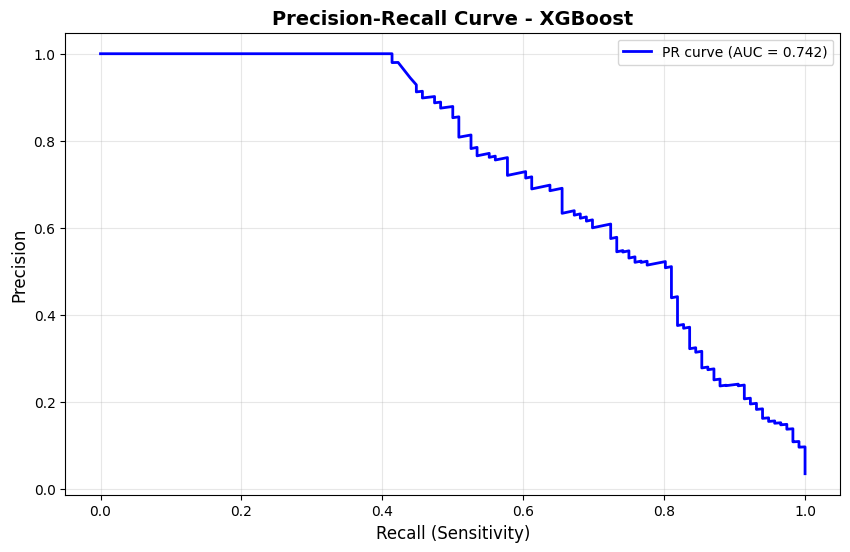

### 🌟 Топ-10 важных признаков (XGBoost):

,Признак,Важность
156,Кардиогенный_шок,0.109352
145,GRACE_Высокий_риск,0.092772
153,UA_нестабильная_стенокардия,0.076240
52,Нейтрофилы_абсолютное_значение,0.057453
15,Стентирование_в_анамнезе,0.047955
174,LACTartMax_b,0.034472
154,Синдромный_диагноз,0.030717
117,Креатинин,0.021194
135,РЕКОРД,0.020959
133,ФВ_lt_40,0.018026


In [74]:
model_trained, results = train_and_evaluate_model(
    xgb_model, 'XGBoost', X_train, y_train, X_val, y_val, X_test, y_test
)
models_results['XGBoost'] = {'model': model_trained, 'results': results}

### 🚀 Обучение LightGBM...

✅ **LightGBM обучена за 0.84 секунд**

### 📊 Результаты LightGBM:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.783482,0.878598,0.999710,0.991410
Validation,0.657407,0.541985,0.594142,0.950049,0.672832
Test,0.793103,0.613333,0.691729,0.977994,0.794107


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 58

- False Negative (пропущенные смерти) ⚠️: 24

- True Positive (правильные предсказания смерти): 92

❌ **КРИТИЧНО:** Модель пропустила 24 смертельных случаев!

⚠️ **Внимание:** 58 ложных тревог могут привести к ненужным вмешательствам

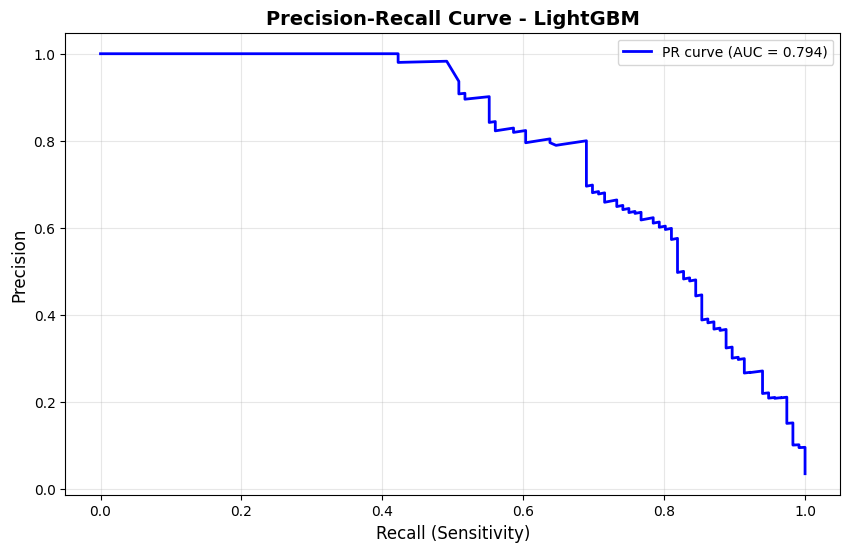

### 🌟 Топ-10 важных признаков (LightGBM):

,Признак,Важность
52,Нейтрофилы_абсолютное_значение,124
22,MKB,91
117,Креатинин,80
39,СДЛА,70
115,ЧСС_b,62
133,ФВ_lt_40,51
1,Age,47
3,STEMI,41
156,Кардиогенный_шок,40
54,Моноциты_абсолютное_значение,36


In [67]:
model_trained, results = train_and_evaluate_model(
        lgb_model, 'LightGBM', X_train, y_train, X_val, y_val, X_test, y_test
    )
models_results['LightGBM'] = {'model': model_trained, 'results': results}

In [80]:
test_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16613 entries, 47 to 17429
Columns: 196 entries, Код пациента to BNP (b)
dtypes: category(67), float64(125), object(4)
memory usage: 17.6+ MB


### 🚀 Обучение CatBoost...

✅ **CatBoost обучена за 1.35 секунд**

### 📊 Результаты CatBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,0.962963,0.376812,0.541667,0.987274,0.795681
Validation,0.787037,0.299296,0.433673,0.943394,0.610517
Test,0.853448,0.339041,0.485294,0.970439,0.737304


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 193

- False Negative (пропущенные смерти) ⚠️: 17

- True Positive (правильные предсказания смерти): 99

❌ **КРИТИЧНО:** Модель пропустила 17 смертельных случаев!

⚠️ **Внимание:** 193 ложных тревог могут привести к ненужным вмешательствам

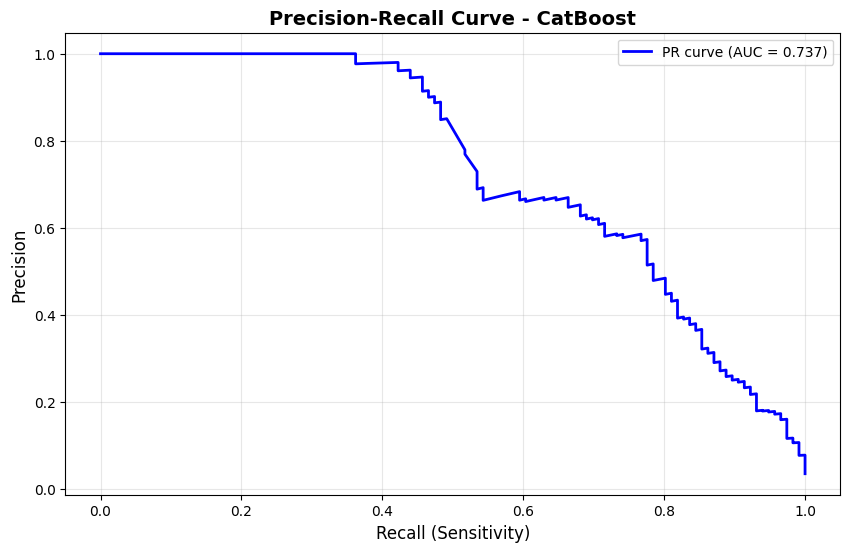

### 🌟 Топ-10 важных признаков (CatBoost):

,Признак,Важность
55,Эозинофилы_абсолютное_значение,10.264112
156,Кардиогенный_шок,9.198577
3,STEMI,5.178373
138,CADILLAC_Низкий_риск,5.018425
117,Креатинин,3.438078
135,РЕКОРД,3.313642
34,КДР_ЛЖ,2.803406
40,Размер_правого_желудочка,2.549930
191,HCO3VenMin_b,2.382005
115,ЧСС_b,2.285655


In [82]:
model_trained, results = train_and_evaluate_model(
    cat_model, 'CatBoost', X_train, y_train, X_val, y_val, X_test, y_test, X_clean.select_dtypes(include=['category', 'object']).columns.tolist()
)
if model_trained is not None:
    models_results['CatBoost'] = {'model': model_trained, 'results': results}

-------------------------------

### Делим на STEMI

In [115]:
test_stemi_yes = test_table[test_table["STEMI"] == "Да"]
test_stemi_no = test_table[test_table["STEMI"] == "Нет"]

In [116]:
test_stemi_yes['Смерть'] = test_stemi_yes['Смерть'].map({'Да': 1, 'Нет': 0})
test_stemi_yes.dropna(subset=['Смерть'], inplace=True)

test_stemi_no['Смерть'] = test_stemi_no['Смерть'].map({'Да': 1, 'Нет': 0})
test_stemi_no.dropna(subset=['Смерть'], inplace=True)

/tmp/ipykernel_200/2803333966.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_stemi_yes['Смерть'] = test_stemi_yes['Смерть'].map({'Да': 1, 'Нет': 0})
/tmp/ipykernel_200/2803333966.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_stemi_yes.dropna(subset=['Смерть'], inplace=True)
/tmp/ipykernel_200/2803333966.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [117]:
test_stemi_no

,Код пациента,Name,Age,Sex,STEMI,ЧКВ,Вид STEMI,Инфаркт-зависимая артерия,Поражение ствола,Количество пораженных сосудов(Syntax),...,PCO2VenMax (b),ScvO2Min (b),ScvO2Max (b),LactVenMin (b),LactVenMax (b),BEVenMin (b),BEVenMax (b),HCO3VenMin (b),HCO3VenMax (b),BNP (b)
47,17-12105,Бабаев СН,59.0,М,Нет,Да,nan,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,17-17180,Ползиков СВ,58.0,М,Нет,Да,nan,2,Нет,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,15536,Анфёров ЮА,74.0,М,Нет,Да,nan,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,17-20825,Кондрашин АА,31.0,М,Нет,Нет,nan,0,Нет,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
687,14668,Мелещенко АВ,43.0,nan,Нет,Да,nan,ПМЖВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6494,20-16149,Хаченков ВН,66.0,М,Нет,Да,nan,ПКА - Несовадает,Нет,2.0,...,38.4,82.6,82.6,2.9,2.9,-1.6,-1.6,22.8,22.8,NaN
6495,18-11214,Чайка СП,64.0,М,Нет,Да,nan,ПМЖВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6497,19-10494,Шеремета ВА,54.0,М,Нет,Да,nan,ОВ - Несовадает,Нет,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6498,8235,Шибе СИ,55.0,М,Нет,Да,nan,ПКА - Несовадает,Нет,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [118]:
X = test_stemi_yes.drop(['Смерть'], axis=1)
y = test_stemi_yes['Смерть']

In [119]:
def clean_column_names(df):
    """
    Очищает имена колонок от символов, которые не принимает XGBoost
    """
    new_columns = []
    for col in df.columns:
        # Удаляем запрещенные символы
        clean_col = col.replace('[', '_').replace(']', '_').replace('<', '_lt_')
        # Удаляем другие потенциально проблемные символы
        clean_col = clean_col.replace('>', '_gt_').replace(' ', '_').replace(':', '_')
        clean_col = clean_col.replace('(', '_').replace(')', '_').replace(',', '_')
        clean_col = clean_col.replace('{', '_').replace('}', '_').replace('|', '_')
        # Удаляем последовательные подчеркивания
        clean_col = '_'.join(filter(None, clean_col.split('_')))
        # Удаляем подчеркивания в начале и конце
        clean_col = clean_col.strip('_')
        # Если имя начинается с цифры, добавляем префикс
        if clean_col and clean_col[0].isdigit():
            clean_col = 'f_' + clean_col
        new_columns.append(clean_col)
    
    # Создаем копию DataFrame с новыми именами колонок
    df_clean = df.copy()
    df_clean.columns = new_columns
    return df_clean

# Применяем к вашим данным
X_clean = clean_column_names(X)

In [120]:
object_cols = X_clean.select_dtypes(include=['object']).columns

In [121]:
from sklearn.preprocessing import LabelEncoder

for col in object_cols:
    le = LabelEncoder()
    # Обучаем encoder на объединённых данных, чтобы избежать ошибок с новыми категориями в тесте
    combined = pd.concat([X_clean[col], X_clean[col]], axis=0).astype(str)
    le.fit(combined)
    X_clean[col] = le.transform(X_clean[col].astype(str))

In [122]:
X_clean.drop(['Код_пациента', ], axis=1, inplace=True)

In [139]:
from sklearn.model_selection import GroupShuffleSplit

# ШАГ 1: отделяем TEST (20% групп)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.08, random_state=42)
train_val_idx, test_idx = next(gss1.split(X_clean, y, test_stemi_yes['Name']))

# Получаем индексы для train+val и test
X_train_val = X_clean.iloc[train_val_idx]
y_train_val = y.iloc[train_val_idx]
groups_train_val = test_stemi_yes['Name'].iloc[train_val_idx]

# ШАГ 2: из оставшихся групп отделяем VALIDATION
# Доля валидации от ОСТАВШИХСЯ данных: val_frac = val_size / (train_size+val_size)
# Допустим, мы хотим train=0.6, val=0.2, test=0.2 от исходного датасета.
# Тогда val_frac = 0.2 / (0.6+0.2) = 0.25
val_frac = 0.08   # 25% от train_val
gss2 = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=42)
train_idx, val_idx = next(gss2.split(X_train_val, y_train_val, groups_train_val))

# Теперь train_idx, val_idx, test_idx – это индексы внутри ИСХОДНОГО датафрейма?
# Нет, нужно быть внимательным: gss2 вернул индексы относительно X_train_val, а не исходного df.
# Чтобы получить окончательные индексы в исходном df, делаем так:
train_idx_original = train_val_idx[train_idx]
val_idx_original   = train_val_idx[val_idx]

# Теперь можно сформировать финальные выборки
X_train = X_clean.iloc[train_idx_original]
X_val   = X_clean.iloc[val_idx_original]
X_test  = X_clean.iloc[test_idx]

y_train = y.iloc[train_idx_original]
y_val   = y.iloc[val_idx_original]
y_test  = y.iloc[test_idx]

# Проверяем, что группы не пересекаются
print("Пациенты в train:", set(test_stemi_yes.iloc[train_idx_original]['Name']))
print("Пациенты в val:  ", set(test_stemi_yes.iloc[val_idx_original]['Name']))
print("Пациенты в test: ", set(test_stemi_yes.iloc[test_idx]['Name']))

Пациенты в train: {'Шабалина СВ', 'Аксенов ВВ', 'Шашкова ЕЛ', 'Иванова ВП', 'Кудрин АА', 'Шаповалова ЕД', 'Грищенко АГ', 'Винарцев ВВ', 'Тулупов ВВ', 'Рихтер МП', 'Ващенко НГ', 'Зарубин ИЗ', 'Воротеляк АА', 'Филимонова РА', 'Костенко АИ', 'Жаботаев АС', 'Чепсакова СА', 'Давыдов ВШ', 'Тихомиров ВА', 'Кирика КП', 'Фомина ЛК', 'Суржик ОИ', 'Тыжук ВА', 'Заднепренко ВИ', 'Кушнер ГГ', 'Лысенко ТВ', 'Марыгина СВ', 'Чепа ЕЕ', 'Кривоносов АМ', 'Макеев ЕВ', 'Старовойтов АА', 'Луканин ВВ', 'Прокопец АА', 'Радюкевич АГ', 'Лозяников АГ', 'Макеева НД', 'Семенов ВА', 'Переведенцев АИ', 'Жога ВА', 'Дудова ЗП', 'Успаленко ВА', 'Шелег АА', 'Балюк КЛ', 'Палей ВВ', 'Братченко НВ', 'Май ЕВ', 'Тихоненко СВ', 'Гресько ВЛ', 'Пасошников ВН', 'Жильцов МС', 'Грицай ГО', 'Погосян РФ', 'Онищук СС', 'Полозов НП', 'Сеславский ВИ', 'Березина НП', 'Махраков ММ', 'Ершов ГА', 'Виноградов ВА', 'Терновская СА', 'Данильченко ВФ', 'Пак Н', 'Гаврилюк ИИ', 'Каздровская МВ', 'Гудименко ГА', 'Смиянов ВН', 'Денисенко АА', 'Калин

In [140]:
sum(y_train), sum(y_val), sum(y_test)

(327.0, 31.0, 38.0)

In [141]:
scale_pos_weight = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

In [142]:
scale_pos_weight

13.807339449541285

In [143]:
def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test, cat_features):
    """
    Обучает модель и оценивает её качество с фокусом на медицинские метрики
    Согласно официальной документации библиотек
    """
    start_time = time.time()
    
    display(Markdown(f"### 🚀 Обучение {model_name}..."))
    
    try:
        # Обучение модели в зависимости от типа (согласно документации)
        if model_name == 'XGBoost':
            dtrain = DMatrix(
                data=X_train, 
                label=y_train,
                enable_categorical=True  # <--- Ключевой параметр
            )

            
            # Согласно документации XGBoost: https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False,
            )
            
        elif model_name == 'LightGBM':
            # Согласно документации LightGBM: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lightgbm.early_stopping(stopping_rounds=50, verbose=False)]  # Корректный синтаксис
            )
            
        elif model_name == 'CatBoost':
            # Согласно документации CatBoost: https://catboost.ai/en/docs/concepts/python-quickstart
            model.fit(
                X_train, y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                verbose=False,
                cat_features=cat_features
            )
        
        train_time = time.time() - start_time
        display(Markdown(f"✅ **{model_name} обучена за {train_time:.2f} секунд**"))
        
        # Предсказания
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        y_pred_test = model.predict(X_test)
        
        # Вероятности для класса 1 (смерть)
        if hasattr(model, "predict_proba"):
            y_proba_train = model.predict_proba(X_train)[:, 1]
            y_proba_val = model.predict_proba(X_val)[:, 1]
            y_proba_test = model.predict_proba(X_test)[:, 1]
        else:
            # Для моделей без predict_proba
            y_proba_train = model.decision_function(X_train)
            y_proba_val = model.decision_function(X_val)
            y_proba_test = model.decision_function(X_test)
        
        # Оценка качества
        results = {}
        
        for dataset_name, y_true, y_pred, y_proba in [
            ('Train', y_train, y_pred_train, y_proba_train),
            ('Validation', y_val, y_pred_val, y_proba_val),
            ('Test', y_test, y_pred_test, y_proba_test)
        ]:
            # Основные метрики
            recall = recall_score(y_true, y_pred)  # Sensitivity - критично в медицине!
            precision = precision_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            roc_auc = roc_auc_score(y_true, y_proba)
            
            # Precision-Recall AUC (важнее ROC-AUC при дисбалансе)
            precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
            pr_auc = auc(recall_curve, precision_curve)
            
            results[dataset_name] = {
                'Recall (Sensitivity)': recall,
                'Precision': precision,
                'F1-score': f1,
                'ROC-AUC': roc_auc,
                'PR-AUC': pr_auc
            }
        
        # Отображение результатов
        display(Markdown(f"### 📊 Результаты {model_name}:"))
        
        # Таблица метрик
        metrics_df = pd.DataFrame(results).T
        display(metrics_df.style.background_gradient(cmap='Blues', subset=['Recall (Sensitivity)', 'PR-AUC']))
        
        # Важно: анализ ошибок для медицины
        display(Markdown("### ⚠️ Анализ ошибок (крайне важно для медицины):"))
        
        # Confusion matrix для тестового набора
        cm = confusion_matrix(y_test, y_pred_test)
        tn, fp, fn, tp = cm.ravel()
        
        display(Markdown(f"**Confusion Matrix (Test set):**"))
        display(Markdown(f"- True Negative (правильные выжившие): {tn}"))
        display(Markdown(f"- False Positive (ложные тревоги): {fp}"))
        display(Markdown(f"- False Negative (пропущенные смерти) ⚠️: {fn}"))
        display(Markdown(f"- True Positive (правильные предсказания смерти): {tp}"))
        
        # Критический анализ
        if fn > 0:
            display(Markdown(f"❌ **КРИТИЧНО:** Модель пропустила {fn} смертельных случаев!"))
        if fp > 0:
            display(Markdown(f"⚠️ **Внимание:** {fp} ложных тревог могут привести к ненужным вмешательствам"))
        
        # Визуализация Precision-Recall кривой (важнее ROC при дисбалансе)
        plt.figure(figsize=(10, 6))
        plt.plot(recall_curve, precision_curve, 'b-', linewidth=2, 
                label=f'PR curve (AUC = {pr_auc:.3f})')
        plt.xlabel('Recall (Sensitivity)', fontsize=12)
        plt.ylabel('Precision', fontsize=12)
        plt.title(f'Precision-Recall Curve - {model_name}', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()
        
        # Важность признаков
        if hasattr(model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'Признак': X_train.columns,
                'Важность': model.feature_importances_
            }).sort_values('Важность', ascending=False)
            
            display(Markdown(f"### 🌟 Топ-10 важных признаков ({model_name}):"))
            display(feature_importance.head(10).style.background_gradient(cmap='Greens'))
        
        return model, results
        
    except Exception as e:
        display(Markdown(f"❌ **Ошибка при обучении {model_name}:** {e}"))
        return None, None

In [144]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    # missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto',  # автоматический выбор метода обучения
    enable_categorical=True
)

# LightGBM - автоматическая обработка пропусков
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    early_stopping_rounds=50  # задается при инициализации
)

# CatBoost - отличная обработка пропусков
cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50  # задается при инициализации
)

In [145]:
models_results = {}

### 🚀 Обучение XGBoost...

✅ **XGBoost обучена за 0.91 секунд**

### 📊 Результаты XGBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.976119,0.987915,0.999995,0.999925
Validation,0.838710,0.812500,0.825397,0.978550,0.920963
Test,0.763158,0.906250,0.828571,0.981951,0.896746


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 3

- False Negative (пропущенные смерти) ⚠️: 9

- True Positive (правильные предсказания смерти): 29

❌ **КРИТИЧНО:** Модель пропустила 9 смертельных случаев!

⚠️ **Внимание:** 3 ложных тревог могут привести к ненужным вмешательствам

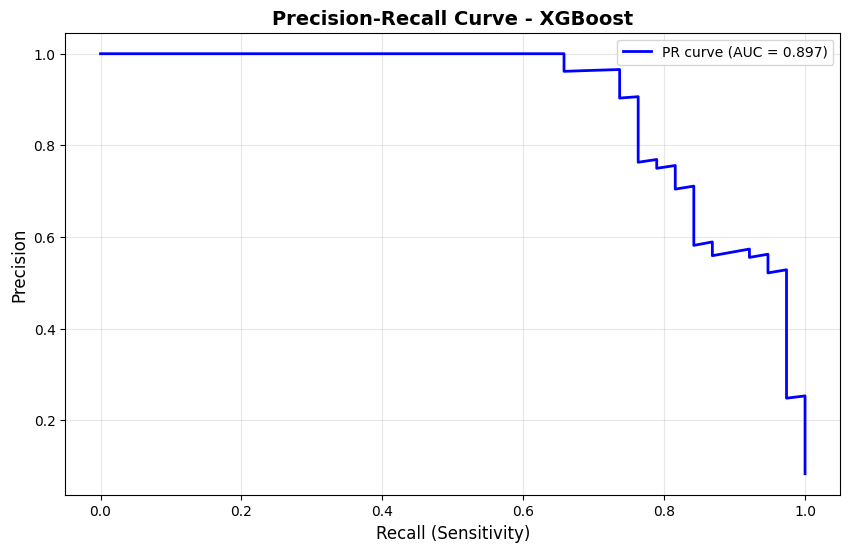

### 🌟 Топ-10 важных признаков (XGBoost):

,Признак,Важность
52,Нейтрофилы_абсолютное_значение,0.125703
39,СДЛА,0.059980
154,Синдромный_диагноз,0.039062
134,CADILLAC,0.038932
55,Эозинофилы_абсолютное_значение,0.030088
156,Кардиогенный_шок,0.024665
22,MKB,0.021370
161,Натрий_Na,0.021082
133,ФВ_lt_40,0.016587
135,РЕКОРД,0.016518


In [146]:
model_trained, results = train_and_evaluate_model(
    xgb_model, 'XGBoost', X_train, y_train, X_val, y_val, X_test, y_test, []
)
models_results['XGBoost'] = {'model': model_trained, 'results': results}

### 🚀 Обучение LightGBM...

✅ **LightGBM обучена за 0.43 секунд**

### 📊 Результаты LightGBM:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.970326,0.984940,1.000000,1.000000
Validation,0.903226,0.756757,0.823529,0.980365,0.924670
Test,0.763158,0.763158,0.763158,0.979743,0.887541


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 9

- False Negative (пропущенные смерти) ⚠️: 9

- True Positive (правильные предсказания смерти): 29

❌ **КРИТИЧНО:** Модель пропустила 9 смертельных случаев!

⚠️ **Внимание:** 9 ложных тревог могут привести к ненужным вмешательствам

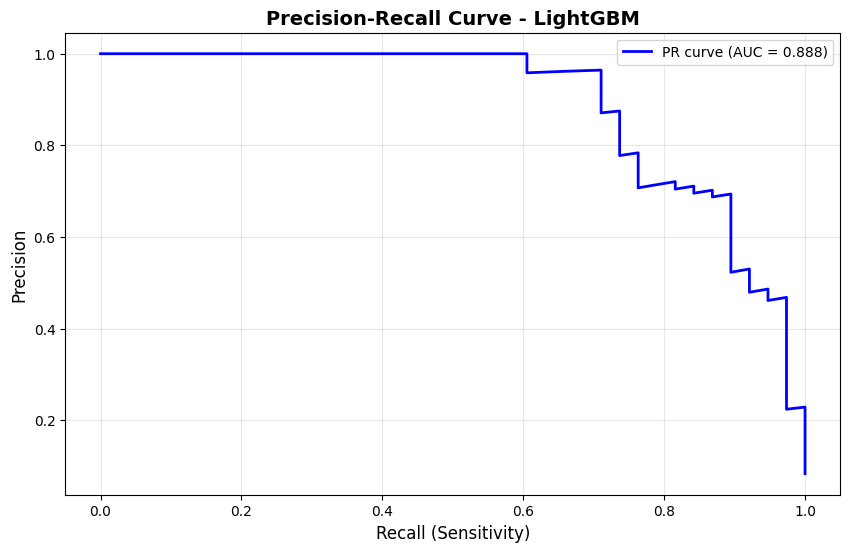

### 🌟 Топ-10 важных признаков (LightGBM):

,Признак,Важность
52,Нейтрофилы_абсолютное_значение,86
126,Стенокардия_в_диагнозе_при_поступлении,70
117,Креатинин,66
118,СКФ,55
115,ЧСС_b,55
39,СДЛА,55
83,Глюкоза_в_мг/дл,48
106,GRACE_Общее,47
133,ФВ_lt_40,45
1,Age,40


In [147]:
model_trained, results = train_and_evaluate_model(
        lgb_model, 'LightGBM', X_train, y_train, X_val, y_val, X_test, y_test, []
    )
models_results['LightGBM'] = {'model': model_trained, 'results': results}

### 🚀 Обучение CatBoost...

✅ **CatBoost обучена за 1.12 секунд**

### 📊 Результаты CatBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,0.984709,0.673640,0.800000,0.996613,0.956391
Validation,0.838710,0.565217,0.675325,0.979540,0.880067
Test,0.815789,0.553571,0.659574,0.971539,0.846774


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 25

- False Negative (пропущенные смерти) ⚠️: 7

- True Positive (правильные предсказания смерти): 31

❌ **КРИТИЧНО:** Модель пропустила 7 смертельных случаев!

⚠️ **Внимание:** 25 ложных тревог могут привести к ненужным вмешательствам

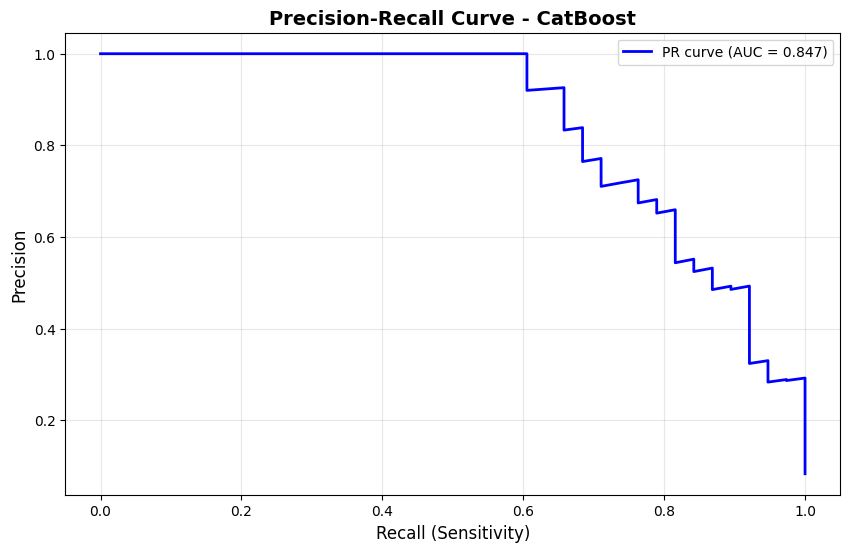

### 🌟 Топ-10 важных признаков (CatBoost):

,Признак,Важность
162,Калий_K,6.122261
55,Эозинофилы_абсолютное_значение,5.462954
76,BLR_базофилы_абс/лимфоциты_абс,5.014304
39,СДЛА,4.183122
126,Стенокардия_в_диагнозе_при_поступлении,3.078429
122,Аортальный_стеноз_Градиент,3.026108
133,ФВ_lt_40,2.951237
35,КСР_ЛЖ,2.749078
135,РЕКОРД,2.705322
52,Нейтрофилы_абсолютное_значение,2.603471


In [148]:
model_trained, results = train_and_evaluate_model(
    cat_model, 'CatBoost', X_train, y_train, X_val, y_val, X_test, y_test, X_clean.select_dtypes(include=['category', 'object']).columns.tolist()
)
if model_trained is not None:
    models_results['CatBoost'] = {'model': model_trained, 'results': results}

In [149]:
comparison_data = []
    
for model_name, data in models_results.items():
    results = data['results']
    test_metrics = results['Test']
    
    comparison_data.append({
        'Модель': model_name,
        'Recall (Sensitivity)': test_metrics['Recall (Sensitivity)'],
        'Precision': test_metrics['Precision'],
        'F1-score': test_metrics['F1-score'],
        'PR-AUC': test_metrics['PR-AUC'],
        'ROC-AUC': test_metrics['ROC-AUC']
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('Recall (Sensitivity)', ascending=False)

display(Markdown("### 🏆 Сравнение моделей на тестовом наборе:"))
display(comparison_df.style.background_gradient(
    cmap='Blues', 
    subset=['Recall (Sensitivity)', 'PR-AUC']
).format({
    'Recall (Sensitivity)': '{:.3f}',
    'Precision': '{:.3f}',
    'F1-score': '{:.3f}',
    'PR-AUC': '{:.3f}',
    'ROC-AUC': '{:.3f}'
}))

# Рекомендация по выбору модели
best_recall_model = comparison_df.iloc[0]['Модель']
best_pr_auc_model = comparison_df.sort_values('PR-AUC', ascending=False).iloc[0]['Модель']

display(Markdown("## 🎯 Рекомендации по выбору модели:"))

if best_recall_model == best_pr_auc_model:
    display(Markdown(f"### ✅ **{best_recall_model} показала лучшие результаты по всем ключевым метрикам**"))
else:
    display(Markdown(f"### 🔍 **Разные модели лидируют по разным метрикам:**"))
    display(Markdown(f"- **Лучший Recall (чувствительность):** {best_recall_model} - приоритет для медицины!"))
    display(Markdown(f"- **Лучший PR-AUC:** {best_pr_auc_model} - баланс precision/recall"))

### 🏆 Сравнение моделей на тестовом наборе:

,Модель,Recall (Sensitivity),Precision,F1-score,PR-AUC,ROC-AUC
2,CatBoost,0.816,0.554,0.660,0.847,0.972
0,XGBoost,0.763,0.906,0.829,0.897,0.982
1,LightGBM,0.763,0.763,0.763,0.888,0.980


## 🎯 Рекомендации по выбору модели:

### 🔍 **Разные модели лидируют по разным метрикам:**

- **Лучший Recall (чувствительность):** CatBoost - приоритет для медицины!

- **Лучший PR-AUC:** XGBoost - баланс precision/recall

In [151]:
list(models_results.keys())

['XGBoost', 'LightGBM', 'CatBoost']

## 📊 Диагностика текущих результатов

### Confusion Matrix для XGBoost:

,Predicted 0,Predicted 1
Actual 0 (Выжил),414,3
Actual 1 (Умер),9,29


### Критические метрики:

- **Recall (Sensitivity) для смерти:** 0.763

- **Количество пропущенных смертей (FN):** 9 из 38

- **Precision для смерти:** 0.906

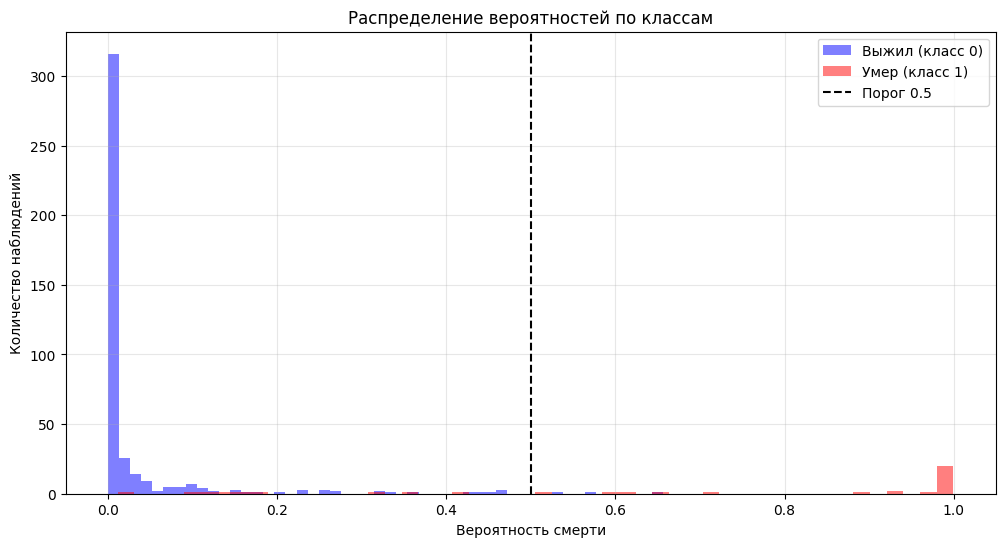

In [152]:
# %% [markdown]
# ## 🔍 Шаг 1: Диагностика текущего состояния моделей

# %%
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Анализ предсказаний лучшей модели
# best_model_name = list(models_results.keys())[0]  # или выберите лучшую по Recall
best_model_name = 'XGBoost'
best_model = models_results[best_model_name]['model']

# Получаем предсказания
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

display(Markdown("## 📊 Диагностика текущих результатов"))
display(Markdown(f"### Confusion Matrix для {best_model_name}:"))
cm_df = pd.DataFrame(cm, 
                    index=['Actual 0 (Выжил)', 'Actual 1 (Умер)'], 
                    columns=['Predicted 0', 'Predicted 1'])
display(cm_df)

display(Markdown(f"### Критические метрики:"))
display(Markdown(f"- **Recall (Sensitivity) для смерти:** {tp/(tp+fn):.3f}"))
display(Markdown(f"- **Количество пропущенных смертей (FN):** {fn} из {tp+fn}"))
display(Markdown(f"- **Precision для смерти:** {tp/(tp+fp):.3f}"))

# Распределение вероятностей
plt.figure(figsize=(12, 6))
plt.hist(y_proba_test[y_test == 0], bins=50, alpha=0.5, label='Выжил (класс 0)', color='blue')
plt.hist(y_proba_test[y_test == 1], bins=50, alpha=0.5, label='Умер (класс 1)', color='red')
plt.axvline(x=0.5, color='k', linestyle='--', label='Порог 0.5')
plt.xlabel('Вероятность смерти')
plt.ylabel('Количество наблюдений')
plt.title('Распределение вероятностей по классам')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Проверка: есть ли вообще предсказания класса 1?
if tp + fp == 0:
    display(Markdown("❌ **КРИТИЧЕСКАЯ ПРОБЛЕМА:** Модель вообще не предсказывает класс 1 (смерть)!"))
    display(Markdown("Это означает, что модель считает всех пациентов выжившими."))

### Optuna

In [153]:
import pandas as pd
import numpy as np
import optuna
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (recall_score, precision_score, f1_score,
                             roc_auc_score, precision_recall_curve, auc,
                             confusion_matrix, classification_report)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use('seaborn-v0_8-whitegrid')

In [155]:
spw = scale_pos_weight

In [ ]:
def optimize_model(model_name, trial):
    """Единая objective-функция для Optuna (исправлено под API >= 1.6)"""
    if model_name == 'XGBoost':
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 80),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 70),
            'subsample': trial.suggest_float('subsample', 0.1, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 10.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 30.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 30.0, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', spw*0.5, spw*2.0),
            'tree_method': 'hist', 'eval_metric': 'logloss',
            'random_state': 42, 'verbosity': 0, 'enable_categorical': True,
            'callbacks': [xgb.callback.EarlyStopping(rounds=50, save_best=True)]
        }

        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        
    elif model_name == 'LightGBM':
        max_depth = trial.suggest_int('max_depth', 3, 10)
        
        # Безопасная динамическая граница: не больше 2^depth и не больше практического потолка
        max_leaves = max(15, min(2**max_depth, 255))  # 255 покрывает 99% задач, >512 почти всегда вредит
        num_leaves = trial.suggest_int('num_leaves', 15, max_leaves)
        
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
            'num_leaves': num_leaves,
            'max_depth': max_depth,
            'min_child_samples': trial.suggest_int('min_child_samples', 1, 300),
            'subsample': trial.suggest_float('subsample', 0.1, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 30.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 30.0, log=True),
            'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
            'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', {0:1, 1:spw}]),
            'random_state': 42, 'verbose': -1
        }
        model = LGBMClassifier(**params)
        # ✅ LightGBM принимает callbacks в fit()
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        
    elif model_name == 'CatBoost':
        params = {
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.5, log=True),
            'depth': trial.suggest_int('depth', 1, 100),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
            'subsample': trial.suggest_float('subsample', 0.1, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.1, 1.0),
            'border_count': trial.suggest_int('border_count', 32, 512),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'random_strength': trial.suggest_float('random_strength', 0.0, 50.0),
            'class_weights': trial.suggest_categorical('class_weights', [None, [1, spw]]),
            'boosting_type': 'Ordered', 'eval_metric': 'Logloss',
            'random_state': 42, 'verbose': False
        }
        model = CatBoostClassifier(**params)
        # ✅ CatBoost использует early_stopping_rounds в fit()
        model.fit(X_train, y_train, eval_set=(X_val, y_val),
                  early_stopping_rounds=50, use_best_model=True, verbose=False, cat_features=X_train.select_dtypes(include=['category']).columns.tolist())
        
    # Метрика оптимизации: PR-AUC на валидации
    proba = model.predict_proba(X_val)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, proba)
    return auc(rec, prec)

import optuna
import optuna.visualization as opt_vis

best_params = {}
studies = {}  # ← сохраняем study для графиков

for name in ['XGBoost', 'LightGBM', 'CatBoost']:
    print(f"\n🔍 Тюнинг {name}...")
    study = optuna.create_study(direction='maximize', study_name=f'{name}_study')
    study.optimize(lambda trial: optimize_model(name, trial), n_trials=500, show_progress_bar=True)
    
    best_params[name] = study.best_params
    studies[name] = study  # ← сохраняем
    print(f"✅ Best PR-AUC: {study.best_value:.4f}")


🔍 Тюнинг XGBoost...


  0%|          | 0/500 [00:00<?, ?it/s]

✅ Best PR-AUC: 0.9381

🔍 Тюнинг LightGBM...


  0%|          | 0/500 [00:00<?, ?it/s]

In [161]:
print("Hello world")

Hello world


In [162]:
for name, study in studies.items():
    print(f"\n📈 Интерактивные графики Optuna для {name}:")
    
    # 1. История оптимизации
    fig1 = opt_vis.plot_optimization_history(study)
    fig1.update_layout(title=f'Optimization History | {name}', height=400)
    fig1.show()
    
    # 2. Важность гиперпараметров (какие параметры сильнее всего влияют на метрику)
    if len(study.trials) > 2:
        fig2 = opt_vis.plot_param_importances(study)
        fig2.update_layout(title=f'Parameter Importances | {name}', height=400)
        fig2.show()
    
    # 3. Параллельные координаты (визуализация многомерного поиска)
    fig3 = opt_vis.plot_parallel_coordinate(study)
    fig3.update_layout(title=f'Parallel Coordinate | {name}', height=500)
    fig3.show()
    
    # 4. Slice plot (влияние каждого параметра на целевую метрику)
    fig4 = opt_vis.plot_slice(study)
    fig4.update_layout(title=f'Slice Plot | {name}', height=450)
    fig4.show()
    
    # 5. Contour plot (взаимодействие двух самых важных параметров)
    top_params = list(study.best_params.keys())[:2]
    if len(top_params) >= 2:
        fig5 = opt_vis.plot_contour(study, params=top_params)
        fig5.update_layout(title=f'Contour ({top_params[0]} vs {top_params[1]}) | {name}', height=450)
        fig5.show()


📈 Интерактивные графики Optuna для XGBoost:



📈 Интерактивные графики Optuna для LightGBM:


TypeError: unhashable type: 'dict'

----------------------

In [305]:
comparison_data = []
    
for model_name, data in models_results.items():
    results = data['results']
    test_metrics = results['Test']
    
    comparison_data.append({
        'Модель': model_name,
        'Recall (Sensitivity)': test_metrics['Recall (Sensitivity)'],
        'Precision': test_metrics['Precision'],
        'F1-score': test_metrics['F1-score'],
        'PR-AUC': test_metrics['PR-AUC'],
        'ROC-AUC': test_metrics['ROC-AUC']
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('Recall (Sensitivity)', ascending=False)

display(Markdown("### 🏆 Сравнение моделей на тестовом наборе:"))
display(comparison_df.style.background_gradient(
    cmap='Blues', 
    subset=['Recall (Sensitivity)', 'PR-AUC']
).format({
    'Recall (Sensitivity)': '{:.3f}',
    'Precision': '{:.3f}',
    'F1-score': '{:.3f}',
    'PR-AUC': '{:.3f}',
    'ROC-AUC': '{:.3f}'
}))

# Рекомендация по выбору модели
best_recall_model = comparison_df.iloc[0]['Модель']
best_pr_auc_model = comparison_df.sort_values('PR-AUC', ascending=False).iloc[0]['Модель']

display(Markdown("## 🎯 Рекомендации по выбору модели:"))

if best_recall_model == best_pr_auc_model:
    display(Markdown(f"### ✅ **{best_recall_model} показала лучшие результаты по всем ключевым метрикам**"))
else:
    display(Markdown(f"### 🔍 **Разные модели лидируют по разным метрикам:**"))
    display(Markdown(f"- **Лучший Recall (чувствительность):** {best_recall_model} - приоритет для медицины!"))
    display(Markdown(f"- **Лучший PR-AUC:** {best_pr_auc_model} - баланс precision/recall"))

### 🏆 Сравнение моделей на тестовом наборе:

,Модель,Recall (Sensitivity),Precision,F1-score,PR-AUC,ROC-AUC
2,CatBoost,0.897,0.362,0.516,0.736,0.975
1,LightGBM,0.784,0.587,0.672,0.760,0.971
0,XGBoost,0.767,0.563,0.650,0.755,0.972


## 🎯 Рекомендации по выбору модели:

### 🔍 **Разные модели лидируют по разным метрикам:**

- **Лучший Recall (чувствительность):** CatBoost - приоритет для медицины!

- **Лучший PR-AUC:** LightGBM - баланс precision/recall

In [308]:
# Оптимизация порога классификации для максимизации Recall
display(Markdown("## ⚙️ Оптимизация порога классификации"))

best_model_name = best_recall_model  # выбираем модель с лучшим Recall
best_model = models_results[best_model_name]['model']

# Получаем вероятности на тестовом наборе
if hasattr(best_model, "predict_proba"):
    y_proba_test = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba_test = best_model.decision_function(X_test)

# Находим оптимальный порог для максимизации Recall при приемлемом Precision
thresholds = np.arange(0.1, 1, 0.05)  # низкие пороги для максимизации Recall
best_threshold = 0.5
best_recall = 0
min_acceptable_precision = 0.4  # минимально приемлемая точность

for threshold in thresholds:
    y_pred = (y_proba_test >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    if precision >= min_acceptable_precision and recall > best_recall:
        best_recall = recall
        best_threshold = threshold

display(Markdown(f"### 🎯 Оптимальный порог классификации: {best_threshold:.2f}"))
display(Markdown(f"- **Recall при этом пороге:** {best_recall:.3f}"))
display(Markdown(f"- **Precision при этом пороге:** {precision_score(y_test, (y_proba_test >= best_threshold).astype(int)):.3f}"))

## ⚙️ Оптимизация порога классификации

### 🎯 Оптимальный порог классификации: 0.60

- **Recall при этом пороге:** 0.793

- **Precision при этом пороге:** 0.426

In [212]:
# Финальные предсказания с оптимальным порогом
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)
final_recall = recall_score(y_test, y_pred_optimal)
final_precision = precision_score(y_test, y_pred_optimal)
final_f1 = f1_score(y_test, y_pred_optimal)

display(Markdown("### 📊 Финальные метрики с оптимальным порогом:"))
final_metrics_df = pd.DataFrame({
    'Метрика': ['Recall (Sensitivity)', 'Precision', 'F1-score'],
    'Значение': [final_recall, final_precision, final_f1]
})
display(final_metrics_df.style.background_gradient(cmap='Greens', subset=['Значение']))

### 📊 Финальные метрики с оптимальным порогом:

,Метрика,Значение
0,Recall (Sensitivity),0.767241
1,Precision,0.514451
2,F1-score,0.615917


## 📊 Диагностика текущих результатов

### Confusion Matrix для CatBoost:

,Predicted 0,Predicted 1
Actual 0 (Выжил),3013,183
Actual 1 (Умер),12,104


### Критические метрики:

- **Recall (Sensitivity) для смерти:** 0.897

- **Количество пропущенных смертей (FN):** 12 из 116

- **Precision для смерти:** 0.362

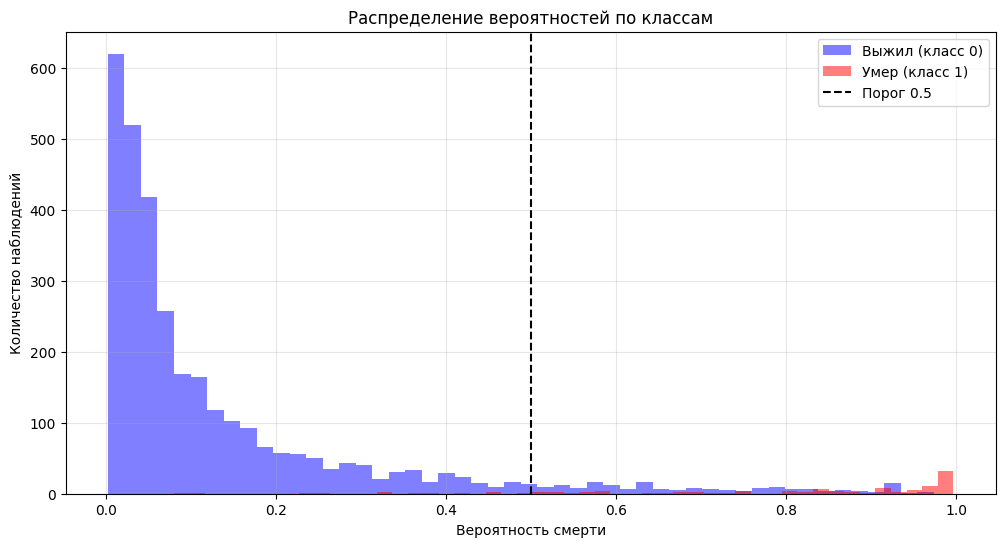

In [309]:
# %% [markdown]
# ## 🔍 Шаг 1: Диагностика текущего состояния моделей

# %%
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Анализ предсказаний лучшей модели
# best_model_name = list(models_results.keys())[0]  # или выберите лучшую по Recall
best_model = models_results[best_model_name]['model']

# Получаем предсказания
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

display(Markdown("## 📊 Диагностика текущих результатов"))
display(Markdown(f"### Confusion Matrix для {best_model_name}:"))
cm_df = pd.DataFrame(cm, 
                    index=['Actual 0 (Выжил)', 'Actual 1 (Умер)'], 
                    columns=['Predicted 0', 'Predicted 1'])
display(cm_df)

display(Markdown(f"### Критические метрики:"))
display(Markdown(f"- **Recall (Sensitivity) для смерти:** {tp/(tp+fn):.3f}"))
display(Markdown(f"- **Количество пропущенных смертей (FN):** {fn} из {tp+fn}"))
display(Markdown(f"- **Precision для смерти:** {tp/(tp+fp):.3f}"))

# Распределение вероятностей
plt.figure(figsize=(12, 6))
plt.hist(y_proba_test[y_test == 0], bins=50, alpha=0.5, label='Выжил (класс 0)', color='blue')
plt.hist(y_proba_test[y_test == 1], bins=50, alpha=0.5, label='Умер (класс 1)', color='red')
plt.axvline(x=0.5, color='k', linestyle='--', label='Порог 0.5')
plt.xlabel('Вероятность смерти')
plt.ylabel('Количество наблюдений')
plt.title('Распределение вероятностей по классам')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Проверка: есть ли вообще предсказания класса 1?
if tp + fp == 0:
    display(Markdown("❌ **КРИТИЧЕСКАЯ ПРОБЛЕМА:** Модель вообще не предсказывает класс 1 (смерть)!"))
    display(Markdown("Это означает, что модель считает всех пациентов выжившими."))

In [214]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint

In [215]:
best_models = {}

xgb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 10),
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 1.5, scale_pos_weight * 2]
}

xgb = XGBClassifier(
    missing=np.nan,
    random_state=42,
    eval_metric='logloss',
    tree_method='auto'
)

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',  # Используем F1 как баланс между precision и recall
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start_time = time.time()
xgb_random.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_train_time = time.time() - start_time

best_xgb = xgb_random.best_estimator_
display(Markdown(f"✅ **XGBoost оптимизирован за {xgb_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{xgb_random.best_params_}\n```"))
display(Markdown(f"**Лучший F1 на кросс-валидации:** {xgb_random.best_score_:.3f}"))

Fitting 3 folds for each of 25 candidates, totalling 75 fits


✅ **XGBoost оптимизирован за 20.24 секунд**

**Лучшие параметры:**

```python
{'colsample_bytree': np.float64(0.7297380084021096), 'gamma': np.float64(0.061043977350336676), 'learning_rate': np.float64(0.11688935142309247), 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 178, 'scale_pos_weight': 27.41025641025641, 'subsample': np.float64(0.8590760482165449)}
```

**Лучший F1 на кросс-валидации:** 0.660

In [216]:
lgb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(15, 60),
    'min_child_samples': randint(5, 30),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'class_weight': [
        {0: 1, 1: scale_pos_weight},
        {0: 1, 1: scale_pos_weight * 1.5},
        {0: 1, 1: scale_pos_weight * 2}
    ]
}

lgb = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgb_random = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=lgb_param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start_time = time.time()
lgb_random.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lightgbm.early_stopping(20, verbose=False)])
lgb_train_time = time.time() - start_time

best_lgb = lgb_random.best_estimator_
display(Markdown(f"✅ **LightGBM оптимизирован за {lgb_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{lgb_random.best_params_}\n```"))
display(Markdown(f"**Лучший F1 на кросс-валидации:** {lgb_random.best_score_:.3f}"))

Fitting 3 folds for each of 25 candidates, totalling 75 fits


✅ **LightGBM оптимизирован за 1623.68 секунд**

**Лучшие параметры:**

```python
{'class_weight': {0: 1, 1: 41.11538461538461}, 'colsample_bytree': np.float64(0.6968221086046001), 'learning_rate': np.float64(0.21164066422176356), 'max_depth': 5, 'min_child_samples': 28, 'n_estimators': 172, 'num_leaves': 31, 'subsample': np.float64(0.8912865394447438)}
```

**Лучший F1 на кросс-валидации:** 0.632

In [217]:
cat_param_dist = {
    'iterations': randint(50, 300),
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(3, 10),
    'l2_leaf_reg': uniform(1, 10),
    'border_count': randint(32, 128),
    'class_weights': [
        [1, scale_pos_weight],
        [1, scale_pos_weight * 1.5],
        [1, scale_pos_weight * 2]
    ]
}

cat = CatBoostClassifier(
    random_state=42,
    verbose=False,
    eval_metric='F1',
    early_stopping_rounds=20
)

# Для CatBoost используем другой подход из-за специфики API
best_score = -1
best_params = None
best_model = None

display(Markdown("🔍 **Запуск рандомизированного поиска для CatBoost...**"))
start_time = time.time()

for i in range(15):  # 15 итераций вместо 25 из-за скорости CatBoost
    params = {
        'iterations': int(randint(50, 300).rvs()),
        'learning_rate': uniform(0.01, 0.3).rvs(),
        'depth': int(randint(3, 10).rvs()),
        'l2_leaf_reg': uniform(1, 10).rvs(),
        'border_count': int(randint(32, 128).rvs()),
        'class_weights': [1, scale_pos_weight * np.random.choice([1.0, 1.5, 2.0])]
    }
    
    model = CatBoostClassifier(
        **params,
        random_state=42,
        verbose=False,
        eval_metric='F1',
        early_stopping_rounds=20
    )
    
    try:
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            use_best_model=True
        )
        
        # Оценка на validation
        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred)
        
        if score > best_score:
            best_score = score
            best_params = params
            best_model = model
        
        if i % 5 == 0:
            display(Markdown(f"Итерация {i+1}/15: F1 = {score:.3f}"))
    
    except Exception as e:
        continue

cat_train_time = time.time() - start_time
best_cat = best_model

display(Markdown(f"✅ **CatBoost оптимизирован за {cat_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{best_params}\n```"))
display(Markdown(f"**Лучший F1 на validation:** {best_score:.3f}"))

🔍 **Запуск рандомизированного поиска для CatBoost...**

Итерация 1/15: F1 = 0.388

Итерация 6/15: F1 = 0.382

Итерация 11/15: F1 = 0.443

✅ **CatBoost оптимизирован за 5.72 секунд**

**Лучшие параметры:**

```python
{'iterations': 270, 'learning_rate': np.float64(0.0885920725683974), 'depth': 8, 'l2_leaf_reg': np.float64(8.377077359625186), 'border_count': 101, 'class_weights': [1, np.float64(27.41025641025641)]}
```

**Лучший F1 на validation:** 0.443

In [219]:
best_models = {
    'XGBoost': best_xgb,
    'LightGBM': best_lgb,
    'CatBoost': best_cat
}

results = []

### 📈 Оценка XGBoost

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.689655
1,Precision,0.792079
2,F1-score,0.737327
3,ROC-AUC,0.980015
4,PR-AUC,0.810307


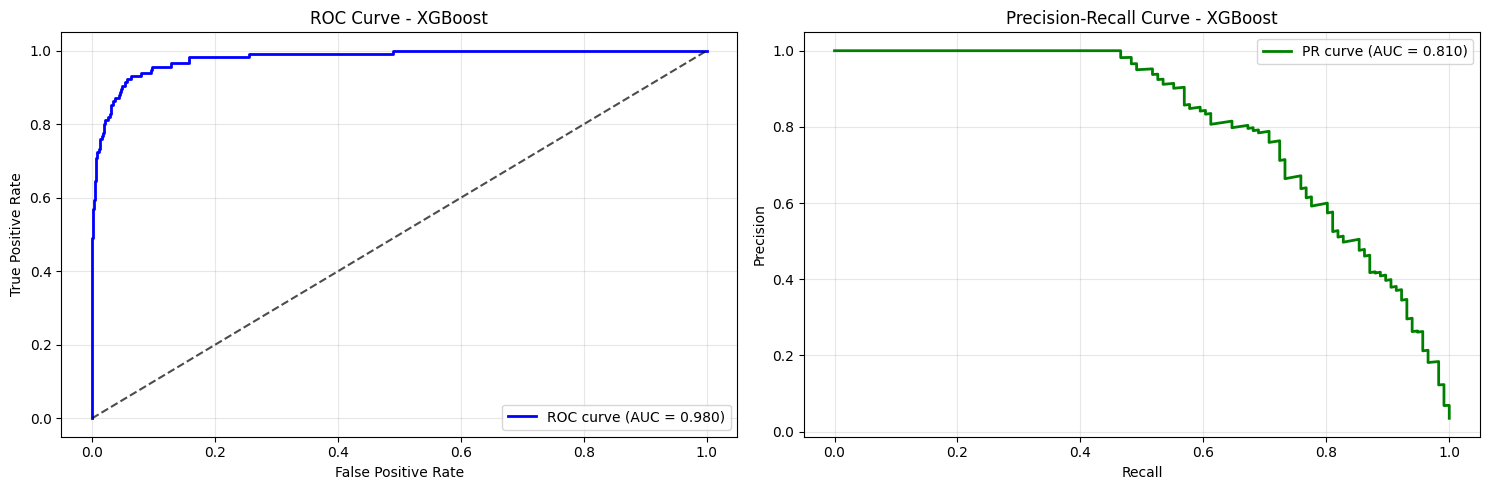

### 📈 Оценка LightGBM

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.741379
1,Precision,0.651515
2,F1-score,0.693548
3,ROC-AUC,0.974777
4,PR-AUC,0.783426


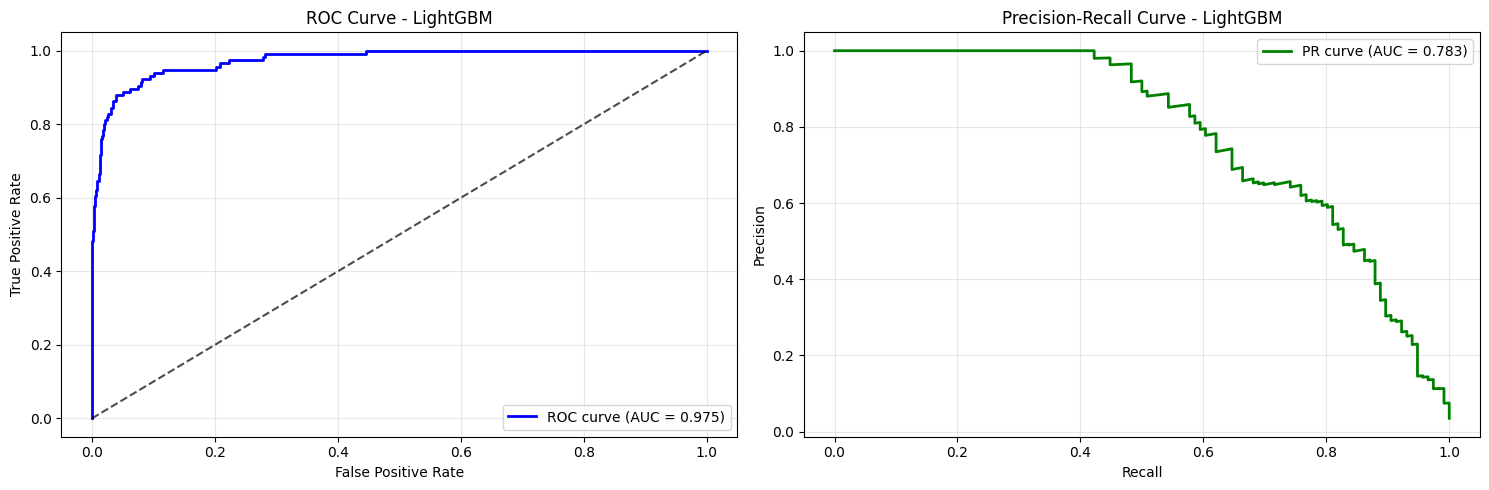

### 📈 Оценка CatBoost

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.844828
1,Precision,0.331081
2,F1-score,0.475728
3,ROC-AUC,0.959725
4,PR-AUC,0.685853


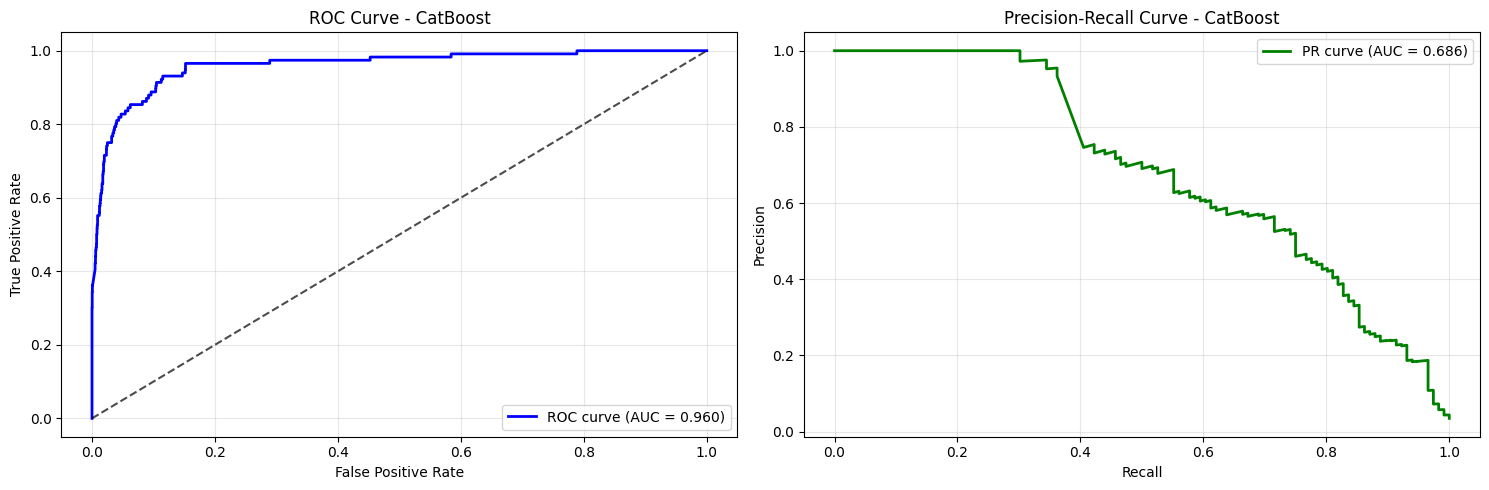

In [220]:
for name, model in best_models.items():
    display(Markdown(f"### 📈 Оценка {name}"))
    
    # Предсказания и вероятности
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Метрики
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Precision-Recall AUC
    from sklearn.metrics import precision_recall_curve, auc
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    results.append({
        'Модель': name,
        'Recall': recall,
        'Precision': precision,
        'F1-score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })
    
    display(Markdown(f"**Метрики на тестовом наборе:**"))
    metrics_df = pd.DataFrame({
        'Метрика': ['Recall', 'Precision', 'F1-score', 'ROC-AUC', 'PR-AUC'],
        'Значение': [recall, precision, f1, roc_auc, pr_auc]
    })
    display(metrics_df.style.background_gradient(cmap='Blues', subset=['Значение']))
    
    # Визуализация кривых
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # ROC кривая
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve - {name}')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Precision-Recall кривая
    ax2.plot(recall_curve, precision_curve, 'g-', linewidth=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve - {name}')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [221]:
results_df = pd.DataFrame(results)
display(Markdown("## 🏆 Сравнение оптимизированных моделей:"))
display(results_df.sort_values('F1-score', ascending=False)
       .style.background_gradient(cmap='Blues', subset=['F1-score', 'ROC-AUC'])
       .background_gradient(cmap='Greens', subset=['Recall'])
       .background_gradient(cmap='Oranges', subset=['Precision']))

## 🏆 Сравнение оптимизированных моделей:

,Модель,Recall,Precision,F1-score,ROC-AUC,PR-AUC
0,XGBoost,0.689655,0.792079,0.737327,0.980015,0.810307
1,LightGBM,0.741379,0.651515,0.693548,0.974777,0.783426
2,CatBoost,0.844828,0.331081,0.475728,0.959725,0.685853
